# DTSC 520 · Module 2

# Python Fundamentals

**Fundamentals of Data Science · Eastern University**

---

## Your commission

You've been hired into a university's **Institutional Research** office. Your
supervisor is **Jamie Berrios**, the Chief Data Officer, and she has a problem.

The University Cabinet is writing a five-year strategic plan, and they want to
know what actually supports student success. Berrios has assembled a cohort
dataset including six tables (see chart below) covering high school experience,
undergraduate and graduate experiences, and work experience.

Right now that data is just sitting there. Nobody has looked at it.

> *"I don't need a model yet. I need someone who can open the data, understand
> what it looks like, and tell me what we've actually got. Start there."*
> - J. Berrios

That's what we'll cover this module. By the end you'll have loaded all six tables
in Python, computed summary stats, and printed a schema report for
Berrios. Later modules use the same cohort with better tools:
NumPy in Module 3, pandas in Module 4, MatPlotLib in Module 5.

The data is **synthetic** - generated for this course. No real student records
are used anywhere in DTSC 520.

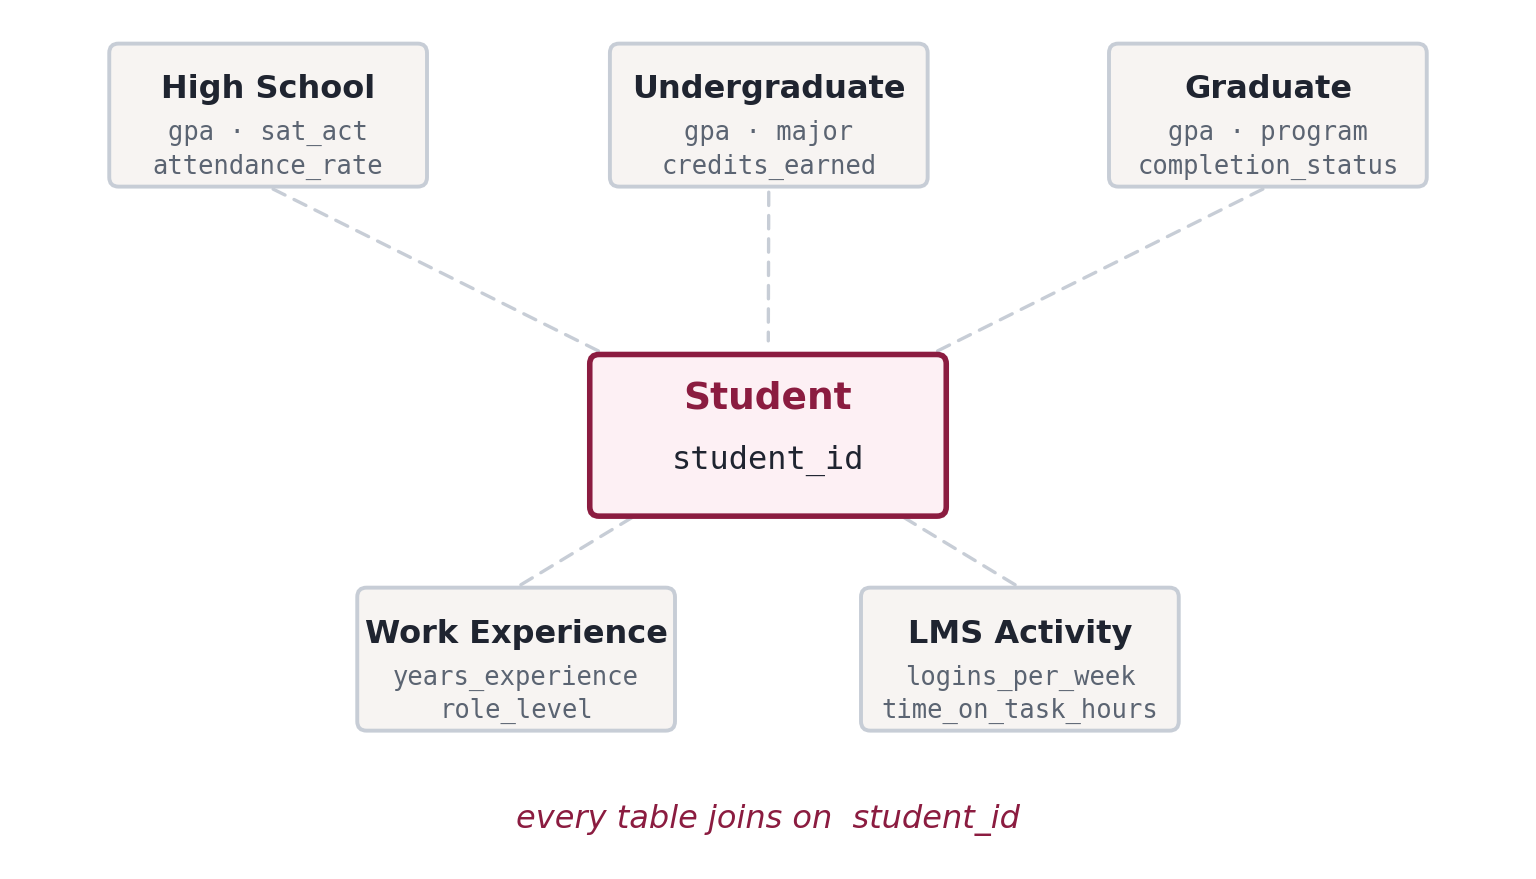

## How to use this notebook

**Run every cell, in order, from the top.** A notebook is not a document you simply
read - it's a combination of text and code you execute a piece at a time. Cells share
one memory, so skipping a cell typically breaks the ones after it. If things get strange, use
*Kernel → Restart & Run All* and start clean.  You will lose none of the code you have created,
but will reset the output.  This almost always fixes the issue.

Three conventions appear throughout:

**Predict cells.** When you see a *Predict* prompt, stop watching the video or scrolling
through the notebook. Say out loud (or write down) what you think the next cell will
output, *then* run it. Being wrong on purpose is how this material sticks - you'll
remember the correction far longer than you'd remember reading the right answer.

**`%%expect` cells.** Some cells are *supposed* to fail. They're marked like
this:

```python
%%expect TypeError
'126' / 3
```

That first line tells the notebook "this should raise a `TypeError`" - so it
prints the error and keeps going instead of stopping, as a notebook typically would.
Read those errors carefully. Learning to recognize them now is much better than
meeting them for the first time on your own.

**Your turn cells.** Exercises. Do them as you go, not at the end.

Run the cell below before anything else. It sets up `%%expect`. You are not
expected to understand it yet.

In [ ]:
# DTSC 520 setup. Run this once, first, every session. Sets up %%expect.
import builtins, sys, traceback
from IPython import get_ipython
from IPython.core.magic import register_cell_magic

@register_cell_magic
def expect(name, cell):
    """%%expect ErrorName -- run a cell that is supposed to fail."""
    want, rule = name.strip() or "Exception", "─" * 64
    try:
        code = compile(cell, "<expected to fail>", "exec")
    except SyntaxError as e:
        raised, tb = e, None
    else:
        try:
            exec(code, get_ipython().user_ns)
            print(f"{rule}\n  NO ERROR RAISED. We expected a {want} here.\n{rule}")
            return
        except BaseException as e:
            raised, tb = e, e.__traceback__.tb_next
    print(f"{rule}\n  EXPECTED ERROR. This cell is supposed to fail.\n{rule}")
    traceback.print_exception(type(raised), raised, tb, limit=4, file=sys.stdout)
    if not isinstance(raised, getattr(builtins, want, ())):
        print(f"\n  (note: expected {want}, got {type(raised).__name__})")

print("Setup complete. %%expect is ready.")

## A word about AI assistants

You will use them. Let's be direct about how.

First, be sure to review Eastern's LLM policies. These will be on syllabi and
in the program handbook.  *It is your responsibility to know these policies.
If you violate them you could face academic discipline including expulsion*

**Good uses.** Paste an error message into an llm and ask what it means. Ask for a second
explanation of a concept when mine didn't land. Ask *why* code works, not just
whether it does. Ask it to generate extra practice problems.

**Bad use.** Pasting an exercise prompt in and submitting what comes back. You
will pass the exercise and fail the course - not because you got caught, but
because every module here assumes you can already do the one before it, and the
capstone assumes all of them.

The line is this: **you are accountable for being able to explain every line you
submit.** If you can't walk me through it, it isn't yours yet. When a model
writes something you don't understand, that's a signal to ask a follow-up
question, not to move on.

More than anything, AI should be used to **learn** - if you're using it without
learning, you're doing it wrong and will be hurt in the long run.

Where I think an assistant is genuinely useful, I'll say so in the exercise.

**How this notebook was made.** The teaching material here is
drawn from the instructor's own course materials and from the textbooks
acknowledged below. AI systems (Claude and Gemini) were used to compare those
sources for concept coverage and divergence, and to draft a notebook
synthesizing them. The sequence, the pedagogy, and every decision about what to
teach are the instructor's. The result has been reviewed and corrected by
Eastern faculty and staff, and verified to execute end to end.

## Sources and acknowledgements

This notebook is a mix. Some of it is original to Eastern University, some is
taken closely from published work, and some is adapted from it. You should know
which is which, both because attribution matters and because the originals are
worth reading on their own.

**Original to Eastern.** The Institutional Research framing and the Berrios
commission, the synthetic cohort and all six tables, the Predict/Run/Debrief
convention, the schema report and cohort briefing, the diagrams, the
AI-assistant policy, and the connective tissue that ties this module to the
capstone. You can learn syntax anywhere.  We're trying to create learning materials
you will enjoy and make you want to keep going.

**[*Think Python*, 3rd edition](https://allendowney.github.io/ThinkPython/), by
Allen B. Downey.** Free online, and the most direct influence here. The
arithmetic-before-variables ordering, the treatment of floor division and
modulus, the `'126' / 3` type-error demonstration, the `1,000,000` tuple
surprise, the illegal-variable-name examples, the "make errors on purpose"
exercise philosophy, and the passage on debugging as emotional management are all
taken from or closely follow Downey. The `%%expect` convention is his idea; the
implementation in this notebook is our own. Chapters 1, 2, 3, 5, 9, and 10
overlap with this module. Licensed CC BY-NC-SA 4.0.

**[*Python Data Science Handbook*](https://jakevdp.github.io/PythonDataScienceHandbook/),
by Jake VanderPlas.** Also free online. It shaped which notebook-craft topics
are worth teaching - the help system, tab completion, `%timeit` - and it is the
reference for the NumPy and pandas material in Modules 3 and 4. Its text is
licensed CC BY-NC-ND, so nothing here reproduces it; the overlap is topic
selection, written fresh.

Errors and infelicities are ours, not theirs.

## The vocabulary

Programming has a precise vocabulary, and using it
precisely is important - it's what lets you ask for or search for help and get an
answer. When you can write "TypeError when concatenating str and int" instead of
"my code is broken," your instructor, GAs, and the internet become useful to you.

Learning these is like learning addition and subtraction in math - you'll use
them in everything you do going forward.

- **operator** - A symbol that performs a computation: `+`, `-`, `**`, `%`, `//`. What it does depends on the types either side of it.
- **expression** - Anything Python can evaluate down to a single value. `2 + 2`, `len(name)`, and `3.81` are all expressions.
- **value** - One piece of data: a number, a string, a list. Everything in Python is a value of some type.
- **type** - The kind of thing a value is - `int`, `float`, `str`, `bool`, `list`, `dict`. Determines which operations are legal on it.
- **statement** - A line that does something rather than producing a value. An assignment, an `if`, a `for`, an `import`.
- **assignment** - Binding a name to a value with `=`. The name is a label, not a box: two names can label the same object.
- **keyword** - A word reserved by the language - `if`, `for`, `def`, `return`, `None`. You cannot use one as a variable name.
- **function** - A named block of code you can run on demand, optionally taking inputs and handing back a result.
- **argument** - The actual value you pass in when you call a function. `print("hi")` passes the argument `"hi"`.
- **parameter** - The name in a function's definition that receives an argument. The parameter is the slot; the argument is what goes in it.
- **return value** - What a function hands back to the code that called it. A function that only prints returns `None`.
- **local variable** - A name created inside a function. It exists while the function runs and is gone afterwards.
- **method** - A function that belongs to an object and is called with a dot: `name.strip()`, `scores.append(3)`.
- **module** - A file of Python code you can `import` and use. `numpy` and `pandas` are modules other people wrote.
- **sequence** - An ordered collection you can index and iterate: a list, a string, a tuple.
- **index** - The position of an item in a sequence, counting from **zero**. `roster[0]` is the first name.
- **slice** - A range taken from a sequence, `start:stop`, where `stop` is **excluded**. `xs[1:3]` gives two items.
- **mapping** - A collection that pairs keys with values rather than positions with values. A dictionary is the mapping you will use.
- **key** - The lookup label in a dictionary. Must be unique and unchangeable; the value it points at can be anything.
- **item** - One key-value pair from a dictionary. `.items()` gives you them as tuples.
- **iteration** - Doing something once per element of a collection. What a `for` loop is for.

---
# 1 · Python as a calculator

We'll start where every programmer starts: arithmetic. It's the fastest way to
get a feel for how Python reads what you type.

Along the way, notice the vocabulary. `30 + 12` is an **expression**. The `+`
is an **operator**. The `42` you get back is a **value**. Small words, but
you'll need them.

In [ ]:
30 + 12

Subtraction uses the minus sign, `-`:

In [ ]:
43 - 1

Multiplication uses the asterisk, `*` - not `×`:

In [ ]:
6 * 7

And division uses the forward slash, `/`:

In [ ]:
84 / 2

Look closely at that last result: `42.0`, not `42`.

Python has two kinds of numbers. An **integer** (`int`) is a whole number. A
**floating-point number** (`float`) can have a fractional part. Division always
produces a float, even when the answer comes out even - because in general
division *can't* be relied on to give a whole number, so Python doesn't pretend
otherwise. `/` always hands back a float, which means you can reason about the
type of the result without knowing the values.

If you want a whole number back, use `//`, called **floor division**:

In [ ]:
84 // 2

In [ ]:
7 // 2

`7 // 2` is `3`, not `3.5` - floor division always rounds *down*,
toward the floor. It throws away the remainder.

Often the remainder is exactly what you want, and for that there's the
**modulus** operator, `%`:

In [ ]:
7 % 2

### Both of these behave surprisingly on negative numbers

"Rounds down" means *down*, not "toward zero." Those are the same thing for
positive numbers and different for negative ones.

> **Predict.** `7 // 2` is `3`. What is `-7 // 2`? Is it `-3` or `-4`?
>
> Commit to an answer before you run the next cell.

In [ ]:
print(-7 // 2)
print(-7 % 2)

**What happened.** `-4` and `1`, and both are worth a second look.

`-7 / 2` is `-3.5`. Rounding *down* from there gives `-4`, because -4 is below
-3.5 on the number line. If you expected `-3` you were rounding toward zero,
which is what most calculators do and what several other languages do.

The modulus is stranger: `-7 % 2` is `1`, not `-1`. In Python the sign of the
result follows the **divisor**, not the dividend. One consequence is genuinely
useful - `n % 2 == 0` correctly identifies even numbers whether `n` is positive
or negative, which is not true in every language.

You will not meet negative numbers often in this course. But when a count or an
index comes out negative unexpectedly, this is a good place to look.

Modulus looks like a curiosity and turns out to be one of the most
useful operators you'll meet. Here's the case that makes it click.

---

Berrios asks how much time a student spent on a task: 105 minutes. You'd like
that as hours and minutes.

In [ ]:
minutes = 105
minutes / 60

`1.75` hours is correct but not how anyone says it. Use `//` for whole hours:

In [ ]:
hours = minutes // 60
hours

And `%` for the minutes left over:

In [ ]:
leftover = minutes % 60
leftover

So: 1 hour and 45 minutes. Two operators, no arithmetic on your part.

Two more modulus tricks worth knowing, because they show up
constantly:

In [ ]:
# the last digit of a number
student_id = 1069
student_id % 10

In [ ]:
# is it even? even numbers have no remainder when divided by 2
14 % 2

In [ ]:
15 % 2

Finally, `**` raises a number to a power:

In [ ]:
7 ** 2

## Order of operations

When an expression has several operators, Python doesn't just work left to
right. It follows the same precedence rules you learned in algebra:
exponentiation first, then multiplication and division, then addition and
subtraction.

> **Predict.** What will `6 + 6 ** 2` produce? Is it `144` or `42`?
>
> Commit to an answer before you run the next cell.

In [ ]:
6 + 6 ** 2

**What happened.** `42`. The exponentiation happened first: `6 ** 2` is `36`, then
`6 + 36`. If Python had worked strictly left to right you'd have gotten
`12 ** 2`, or `144`.

Whitespace makes no difference to Python here: `6+6**2` gives the same answer.
It's only for your eyes.

In [ ]:
12 + 5 * 6

Parentheses override precedence. Use them whenever the order isn't obvious at a glance:

In [ ]:
(12 + 5) * 6

## Arithmetic functions

Python also comes with **functions**. A function takes one or more values,
does something with them, and hands a result back. When you use one, you are
**calling** it, and the value in the parentheses is the **argument**.

`round` rounds a float to the nearest whole number:

In [ ]:
round(42.4)

In [ ]:
round(42.6)

`abs` gives the absolute value - the size of a number, ignoring its sign:

In [ ]:
abs(-42)

In [ ]:
abs(42)

Those parentheses aren't decoration. Leave one out and Python
can't tell where the argument ends, so it gives up before running anything.
That's a **SyntaxError** - the code isn't valid Python at all.

In [ ]:
%%expect SyntaxError
abs(-42

Notice what the error message gives you: the line, a caret pointing
at roughly where Python got confused, and the words `SyntaxError:
'(' was never closed`. That last part is unusually helpful. Most of the time,
Python's guess about *where* the problem is will be close but slightly after the
real mistake - because Python only notices something is wrong once it hits
something that can't possibly follow.

### Your turn

Berrios logged a study session as **227 minutes**. Print how many whole hours
that is, and how many minutes are left over.

Use `//` and `%`. Two lines is plenty.

In [ ]:
### ENTER CODE HERE ###

### Your turn

Here's an oddity worth knowing about. Run both cells below and compare.

In [ ]:
round(42.5)

In [ ]:
round(43.5)

`42.5` rounds down to `42`, but `43.5` rounds up to `44`. That
isn't a bug - Python rounds halves toward the nearest *even* number, a
convention called banker's rounding that avoids a systematic upward bias when
you round thousands of values.

This is a good first thing to ask an AI assistant: *"Why does Python round 0.5
to even instead of always up?"* Compare what it tells you to what you just
observed.

---
# 2 · Values and types

Every value in Python has a **type**, and the type determines what you're
allowed to do with the value. Getting types wrong is probably the single most
common source of errors in data work, so it's worth being deliberate here.

The `type` function tells you what you've got.

In [ ]:
type(42)

In [ ]:
type(42.0)

In [ ]:
type('Amara Okonkwo')

Three types, three uses:

- `int` - a whole number
- `float` - a number with a decimal point
- `str` - a **string**, meaning text (short for "string of characters")

The quotes are what make something a string. `42` is a number; `'42'` is text
that happens to look like a number. Python treats them very differently.

In [ ]:
type(42)

In [ ]:
type('42')

## Why the difference matters

Data arrives from the registrar, and every value in it is text -
that's just how files work. Suppose a GPA came through as the string `'3.81'`
and you try to do arithmetic with it.

> **Predict.** What happens when you divide a string by a number?
>
> Commit to an answer before you run the next cell.

In [ ]:
%%expect TypeError
'126' / 3

**What happened.** A **TypeError**. The message is worth reading closely:
`unsupported operand type(s) for /: 'str' and 'int'`.

Python is telling you exactly what went wrong: the `/` operator doesn't know
how to divide a `str` by an `int`. The values in an expression are called
**operands**, which is where that wording comes from.

This error is not Python being difficult. It's Python refusing to guess. In a
language that guesses, `'126' / 3` might silently produce something wrong, and
you'd find out three steps later.

The fix is to **convert** the string to a number first. `int` works as a function for exactly this:

In [ ]:
int('126') / 3

`float` does the same for values with a decimal point:

In [ ]:
float('3.81')

In [ ]:
float('3.81') * 2

Conversion goes the other way too. `str` turns a number into text:

In [ ]:
str(42)

And `int` on a float throws away the fractional part - it does not round:

In [ ]:
int(42.9)

### A conversion trap

`int` converts a string of digits. It will not convert a string that *looks*
like a float.

In [ ]:
%%expect ValueError
int('3.7')

This one is a **ValueError**, not a TypeError, and the distinction
is useful. A TypeError means *wrong kind of thing*. A ValueError means *right
kind of thing, but its content doesn't work* - `int` accepts strings, this just
isn't a string it can parse.

If you meant to get `3`, convert to float first, then to int:

In [ ]:
int(float('3.7'))

## The comma trap

Write a large number the way you'd write it on paper and Python will not
complain - which is exactly what makes this dangerous.

> **Predict.** What do you get if you store `1,000,000` in a variable and print it?
>
> Commit to an answer before you run the next cell.

In [ ]:
population = 1,000,000
print(population)
print(type(population))

**What happened.** Not a number at all - `(1, 0, 0)`, of type `tuple`.

In Python, commas separate values, so `1,000,000` is three separate integers -
`1`, `0`, and `0` - bundled into something called a **tuple**. No error, no
warning, and every calculation downstream is quietly wrong.

This is the worst kind of bug: the silent kind. If you need a thousands
separator for readability, Python accepts underscores instead.

In [ ]:
1_000_000

In [ ]:
1_000_000 + 1

### Your turn

Below are eight expressions. For each one, write down your guess for the type
*before* running anything, then use `type()` to check.

```
765
2.718
'2 pi'
abs(-7)
abs(-7.0)
abs
int
type
```

The last three are the interesting ones. What is the type of a function
itself?

In [ ]:
### ENTER CODE HERE ###

---
# 3 · Variables and statements

So far every result has vanished the moment it was displayed. A **variable**
lets you keep a value and give it a name.

Naming things is not a convenience. It's most of what makes code readable.

In [ ]:
credits_earned = 124

Notice: **no output**. This is an **assignment statement**, and a
statement performs an action rather than producing a value. It has three parts -
the variable name on the left, the `=` **assignment operator**, and an
expression on the right.

The value is now stored under that name. Ask for the name and you get the
value:

In [ ]:
credits_earned

A variable can hold any type. Here's a float and a string:

In [ ]:
ug_gpa = 3.81
major = 'Data Science'

In [ ]:
major

Once a variable exists, you can use it anywhere you'd use the value itself:

In [ ]:
credits_earned + 6

In [ ]:
ug_gpa * 2

Including as an argument to a function:

In [ ]:
round(ug_gpa)

## Reassignment

A variable's value can change. Assign to the same name again and the old value
is simply gone.

In [ ]:
attempts = 1
attempts = 2
attempts

This is worth pausing on, because the `=` sign is misleading. In
mathematics, `=` asserts that two things *are* equal. In Python, `=` is an
instruction: *take the value on the right and store it under the name on the
left*. It's an action, not a claim.

Which is why this works, and would be nonsense in algebra:

> **Predict.** What is `count` after these two lines?
>
> Commit to an answer before you run the next cell.

In [ ]:
count = 5
count = count + 3
count

**What happened.** `8`. Python evaluates the right side first - `count + 3` is
`5 + 3`, or `8` - and *then* stores that result back under the name `count`.
The old value of `5` is overwritten in the process.

Read `=` as "gets" rather than "equals" and this stops being confusing:
`count` *gets* `count + 3`.

Adding to a variable is common enough that Python has a shorthand.
These two lines do the same thing:

```python
count = count + 3
count += 3
```

In [ ]:
count = 5
count += 3
count

In [ ]:
count -= 2
count

In [ ]:
count *= 10
count

You'll see `+=` constantly once we get to loops, where it's how you
accumulate a running total.

## Variable names

Names can contain letters, digits, and underscores, but they cannot start with
a digit and cannot contain spaces or punctuation. Break those rules and you get
a SyntaxError.

In [ ]:
%%expect SyntaxError
million! = 1000000

In [ ]:
%%expect SyntaxError
76trombones = 'big parade'

There's a third category of illegal name that's less obvious. Some
words are **keywords** - words Python reserves for the structure of the language
itself. You can't use them as variable names.

In [ ]:
%%expect SyntaxError
class = 'Introduction to Data Science'

In [ ]:
%%expect SyntaxError
False = 6

`class` is a keyword because Python uses it to define a class (Module
5 territory). `False` is a built-in constant. There are about thirty-five of
these, and you don't need to memorize them - your editor will color them
differently, which is warning enough.

If you're curious, Python will list them:

In [ ]:
import keyword
print(keyword.kwlist)
print(len(keyword.kwlist), 'keywords')

### Naming style

Legal is a low bar. The convention in Python - and it is a strong one - is
`lowercase_with_underscores` for variables, and names that say what the thing
*is*:

```python
x = 3.81                  # legal, useless
g = 3.81                  # legal, still useless
ug_gpa = 3.81             # good
undergraduate_gpa = 3.81  # also fine, if a little long
```

You will spend far more time reading code than writing it, including your own
code six months from now. `ug_gpa` costs you four extra keystrokes and saves you
a minute of puzzling every time you come back to it.

## Comments

A **comment** starts with `#`. Python ignores everything from the `#` to the end
of the line.

In [ ]:
# minutes a student spent on task, across the whole term
time_on_task = 9.5

Comments can also sit at the end of a line of code:

In [ ]:
attendance = 0.96     # proportion of classes attended, 0 to 1

A comment that restates the code is noise:

```python
gpa = 3.81     # assign 3.81 to gpa
```

A comment that supplies what the code *can't* say is valuable:

```python
gpa = 3.81     # on the 4.0 scale; transfer credits excluded
```

Units, scales, assumptions, and the reason you did something the odd way -
those are what comments are for.

### Your turn

Make some errors on purpose. For each of these, predict what happens, then try
it in the cell below. You'll need to run them one at a time.

1. `17 = n` - we know `n = 17` is fine. Is the reverse?
2. `x = y = 1` - does chained assignment work?
3. Put a semicolon at the end of a statement: `n = 17;`
4. Put a period at the end: `n = 17.`
5. Misspell a module name: `import maath`

Number 4 is sneakier than it looks. Check the *type* of what you get.

In [ ]:
### ENTER CODE HERE ###

---
# 4 · Strings

Time to open the actual data. Berrios sends over the cohort's name field and
immediately apologizes for it:

> *"Fair warning, the names came out of three different systems. They're a
> mess. Whitespace, capitalization, all of it. Clean one by hand first so you
> know what you're dealing with."*

Here's one record.

In [ ]:
raw_name = "  amara OKONKWO  "
raw_name

Note what the output shows you: `'  amara OKONKWO  '`, quotes
included. Those quotes aren't part of the value - they're Python showing you
where the string starts and ends, which is the only way you'd see the leading
and trailing spaces.

A **string** is a sequence of characters in quotes. Single or double quotes both
work and mean exactly the same thing:

In [ ]:
'Eastern University'

In [ ]:
"Eastern University"

Having both is genuinely useful, because it lets you put one kind of
quote inside the other. A name with an apostrophe breaks single quotes:

In [ ]:
%%expect SyntaxError
advisor = 'Berrios' office'

Python read `'Berrios'` as a complete string, then found a stray
`office'` it couldn't make sense of. Two ways out. Use double quotes on the
outside:

In [ ]:
advisor = "Berrios' office"
advisor

Or **escape** the apostrophe with a backslash, which tells Python the next character is data, not syntax:

In [ ]:
advisor = 'Berrios\' office'
advisor

Text without quotes isn't text at all - Python reads it as a
variable name. Two words with a space between them isn't a legal name, so this
one fails before it runs:

In [ ]:
%%expect SyntaxError
name = amara okonkwo

Remove the space and it becomes legal syntax - but there's still no variable called `amara`, so now you get a different error:

In [ ]:
%%expect NameError
name = amara

Two errors, one root cause: **missing quotes**. Worth internalizing,
because it's the mistake that produces the most confusing beginner errors.

## Length, joining, repeating

`len` counts the characters in a string:

In [ ]:
len('Eastern University')

Eighteen - the space counts. `len` counts what's between the quotes, not the quotes themselves.

The `+` operator joins strings end to end. This is called **concatenation**:

In [ ]:
'Eastern' + ' ' + 'University'

Note that you have to supply the space yourself. And `*` repeats a string:

In [ ]:
'-' * 40

Which is a cheap way to draw a divider in a report. The other arithmetic operators don't work on strings:

In [ ]:
%%expect TypeError
'Eastern' - 'East'

## Indexing

A string is a **sequence**, meaning its characters are in a definite order and
each one has a numbered position called an **index**. You get a single character
with square brackets.

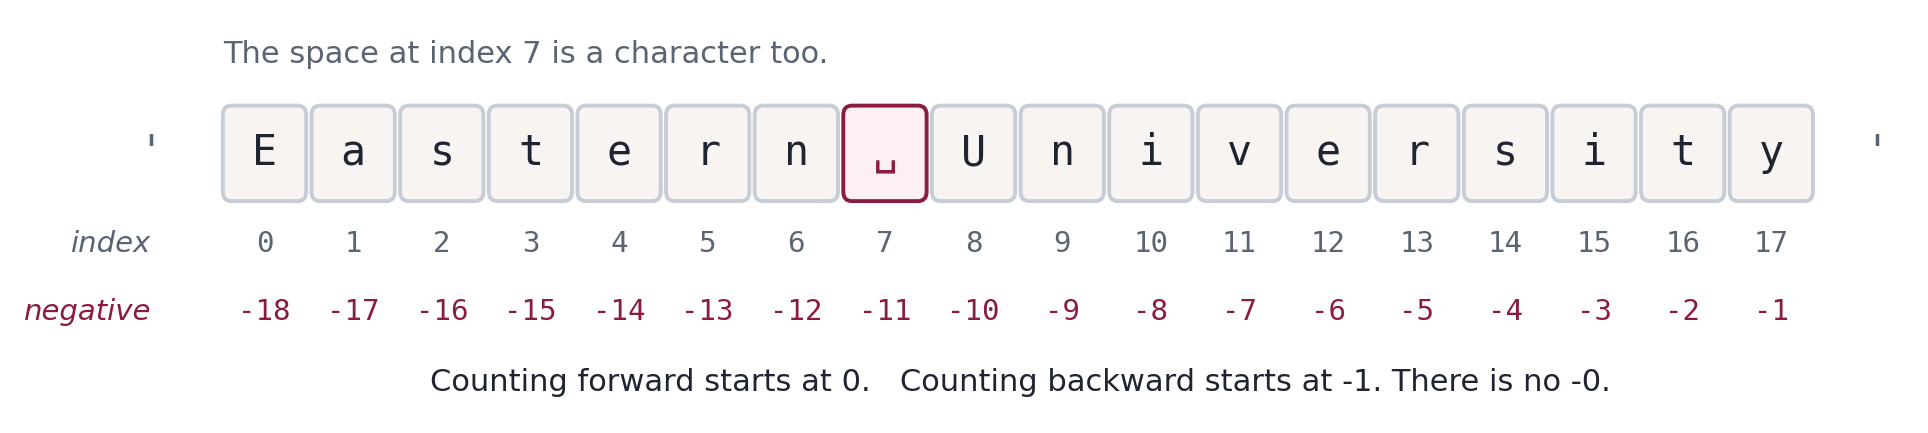

In [ ]:
university = 'Eastern University'
university[0]

**Indexing starts at zero.** `university[0]` is the first
character, not the second. This trips up everyone at first, and it is the single
most common off-by-one mistake in programming. Zero-based indexing is worth
getting into your bones now, because lists, arrays, and DataFrames all work the
same way.

In [ ]:
university[6]

In [ ]:
university[7]

Index 7 is the space. Spaces are characters like any other - a fact that matters a great deal when you're cleaning data.

Negative indices count from the end, which saves you from computing the length first:

In [ ]:
university[-1]

In [ ]:
university[-2]

> **Predict.** The string has 18 characters. What does `university[-0]` give you?
>
> Commit to an answer before you run the next cell.

In [ ]:
university[-0]

**What happened.** `'E'` - the first character, not the last.

There is no `-0`. Zero and negative zero are the same number, so `[-0]` is just
`[0]`. Counting forward starts at `0`; counting backward starts at `-1`. The
asymmetry is annoying but you only have to learn it once.

Ask for an index that doesn't exist and you get an **IndexError**:

In [ ]:
%%expect IndexError
university[18]

The valid indices for an 18-character string are `0` through `17`. `18` is one past the end - which is exactly why the error type has its own name.

## Slicing

A **slice** is a range of characters. The syntax is `[start:stop]`, and the
character at `stop` is *not* included.

In [ ]:
university[0:7]

Seven characters - indices 0 through 6. The stop index is exclusive.

That sounds like a design mistake and isn't: it means `stop - start` is exactly
the length of the slice, and it means `[0:7]` and `[7:18]` fit together with no
overlap and no gap.

In [ ]:
university[8:18]

Leave out the start and the slice runs from the beginning:

In [ ]:
university[:7]

Leave out the stop and it runs to the end:

In [ ]:
university[8:]

Leave out both and you get the whole thing - which looks pointless now but becomes useful with lists:

In [ ]:
university[:]

## f-strings

Here is the feature you might use more than any other in this notebook.

Building output by concatenation gets ugly fast, and it breaks the moment a
number is involved, because you can't concatenate a `str` and an `int`:

In [ ]:
%%expect TypeError
name = 'Amara Okonkwo'
gpa = 3.02
'Student ' + name + ' has GPA ' + gpa

An **f-string** solves this. Put an `f` before the opening quote,
and then anything inside curly braces `{}` is evaluated as Python and dropped
into the text.

In [ ]:
f"Student {name} has GPA {gpa}"

No conversion needed, no manual spaces, and you can read it. Any expression works inside the braces, not just a variable name:

In [ ]:
f"{name} needs {124 - 118} more credits."

In [ ]:
f"Rounded GPA: {round(gpa, 1)}"

You can also control formatting after a colon. `:.2f` means "as a
float with 2 decimal places," which matters when you're reporting numbers to a
Cabinet that will notice `3.8100000000000005`.

In [ ]:
f"GPA to two places: {gpa:.2f}"

In [ ]:
attendance = 0.9612
f"Attendance: {attendance:.1%}"

From here on, this notebook uses f-strings for essentially all
output. Older code uses `%` formatting or `.format()`; you'll recognize them
when you see them, and you don't need to write them.

## String methods

A **method** is a function that belongs to a value. You call it with a dot after
the value: `value.method()`. Strings come with a lot of them, and the cleaning
ones are what Berrios needs.

Back to our messy record:

In [ ]:
raw_name

`.strip()` removes whitespace from both ends. **Only the ends** -
it will not touch anything in the middle of a string. That matters more than it
sounds like it does, and it comes back to bite us in section 8.

In [ ]:
raw_name.strip()

`.lower()` and `.upper()` change case:

In [ ]:
raw_name.lower()

`.title()` capitalizes the first letter of each word - which is what a name field wants:

In [ ]:
raw_name.strip().title()

That line chains two methods: `.strip()` hands back a string, and
`.title()` is then called on *that* string. Reading left to right is reading the
order of operations, which makes chains easy to follow once you notice.

One thing to be clear about: **string methods never modify the original.**

In [ ]:
print(f"cleaned: {raw_name.strip().title()}")
print(f"original: {raw_name}")

`raw_name` is unchanged. Strings are **immutable** - they cannot be
altered in place. Methods hand back a *new* string, and if you want to keep it,
you have to assign it to something.

In [ ]:
clean_name = raw_name.strip().title()
clean_name

`.split()` breaks a string into a list of pieces, splitting on whitespace by default:

In [ ]:
clean_name.split()

Those square brackets mean you've got a **list** - the subject of section 7. For now, note that splitting a full name gives you the parts separately:

In [ ]:
parts = clean_name.split()
print(parts[0])
print(parts[1])

`.split()` takes an optional argument, the **delimiter**, for when the separator isn't a space. CSV files are the obvious case:

In [ ]:
row = '1003,Amara Okonkwo,Biology'
row.split(',')

`.join()` is the reverse - it glues pieces back together with a separator of your choosing:

In [ ]:
' | '.join(['1003', 'Amara Okonkwo', 'Biology'])

The string you call `.join()` on is the glue, which reads backwards until you've done it a few times. And `.replace()` swaps one substring for another:

In [ ]:
'MS Data Science'.replace('MS', 'Master of Science')

### Methods belong to types

Methods aren't universal. `.upper()` is a string method, so a number doesn't
have it.

In [ ]:
%%expect AttributeError
gpa = 3.81
gpa.upper()

An **AttributeError** means *this value has no such thing attached
to it*. Read it as "a float doesn't know how to do `upper`."

This is the error you get most often when a variable holds something other than
what you assumed - which, in data work, is most of the time. When you see an
AttributeError, the useful question isn't "what's wrong with this method," it's
"what type is my variable *actually*?" Check with `type()`.

To see everything a string can do, `dir()` will list the methods (ignore the
ones starting with underscores):

In [ ]:
print(dir(str))

Ignore everything starting with underscores - those are internal.
You don't need to know the rest of that list either. You need to know that it
exists, and that `help(str.strip)` will explain any single item on it.

In [ ]:
help(str.strip)

### Your turn

Berrios needs names formatted as `"Okonkwo, Amara"` for an alphabetical roster.

Starting from `raw_name`, produce that string. You'll need `.strip()`,
`.title()`, `.split()`, indexing, and an f-string.

Do it in as many steps as you like - clarity beats cleverness.

In [ ]:
raw_name = "  amara OKONKWO  "

### ENTER CODE HERE ###

### Your turn

Predict, then check: what does each of these produce? One of them raises an
error - which, and why?

```python
'Eastern'[2:5]
'Eastern'[-3:]
'Eastern'[5:2]
'Eastern'[0] + 'Eastern'[-1]
'Eastern'.strip('n')
len('Eastern'[3:])
'Eastern' + 7
```

In [ ]:
### ENTER CODE HERE ###

---
# 5 · Functions

You've been calling functions since section 1 - `round`, `abs`, `len`, `type`.
Now you'll write your own.

A **function** is a named block of code you can run whenever you want. Four
reasons this matters, and none of them are about saving keystrokes:

- **Naming.** A well-named function tells a reader what a block of code is *for*.
  `clean_name(raw)` says more than six lines of `.strip()` and `.title()`.
- **Repetition.** Write it once, use it ten times. When the logic changes, you
  change one place instead of hunting for ten.
- **Debugging.** You can test a small function on its own. Testing a 200-line
  script as a single unit is how people lose weekends.
- **Reuse.** Berrios's schema report will need the same name-cleaning code the
  Module 4 pipeline needs.

## Defining a function

In [ ]:
def show_commission():
    print("Institutional Research - Academic Success Report")
    print("Prepared for the University Cabinet")

No output. Defining a function doesn't run it - it just stores the
instructions under a name, the same way an assignment stores a value.

Look at the anatomy:

- `def` is the **keyword** that starts a function definition.
- `show_commission` is the name. Any legal variable name is a legal function name.
- The empty parentheses `()` mean this function takes no inputs.
- The first line is the **header** and it must end with a colon.
- The indented lines below are the **body**.

**Indentation is syntax in Python.** In most languages, indenting is a courtesy
to readers; in Python it's how the language knows which lines belong to the
function. Four spaces is the universal convention. Be consistent - mixing tabs
and spaces produces errors that are genuinely hard to see.

Now call it. Parentheses are what trigger the call:

In [ ]:
show_commission()

> **Predict.** What do you get if you leave the parentheses off - `show_commission` with no `()`?
>
> Commit to an answer before you run the next cell.

In [ ]:
show_commission

**What happened.** Not the output - a description of the function object itself.

Without parentheses you're referring to the function as a *value*, the same way
`gpa` refers to a number. With parentheses you're telling Python to *run* it.
This distinction shows up again in Module 4, where you hand functions to pandas
as arguments without calling them.

## Parameters

A function that always does the same thing has limited use. A **parameter** is a
variable in the header that receives a value when the function is called.

In [ ]:
def print_heading(text):
    print(text)
    print("=" * len(text))

In [ ]:
print_heading("Cohort Summary")
print_heading("Engagement")

One definition, different output each time.

Two words that get used loosely and shouldn't be:

- a **parameter** is the name in the function definition (`text`)
- an **argument** is the actual value you pass in (`"Cohort Summary"`)

The parameter is the slot; the argument is what you put in it. Error messages
use both words precisely, so it pays to know which is which.

You can pass a variable as the argument - the *value* gets handed over, and the
parameter name inside the function is unrelated to the variable name outside:

In [ ]:
report_title = "Term Report"
print_heading(report_title)

Give the wrong number of arguments and you get a `TypeError`, with a
message that names the function and counts the arguments for you:

In [ ]:
%%expect TypeError
print_heading()

In [ ]:
%%expect TypeError
print_heading("Cohort", "Summary")

## Return values - the important distinction

This is the concept students most often get halfway. Take it slowly.

`print` puts text on the screen for a human to read. `return` hands a value back
to the program so it can be used. They are not alternatives to each other; they
do different jobs.

Here is a function that prints:

In [ ]:
def show_letter_grade(gpa):
    if gpa >= 3.5:
        print("A")
    else:
        print("B or below")

In [ ]:
show_letter_grade(3.81)

Looks like it works. Now try to *use* the result:

> **Predict.** What will `result` be after `result = show_letter_grade(3.81)`? What will its type be?
>
> Commit to an answer before you run the next cell.

In [ ]:
result = show_letter_grade(3.81)
print(f"result is {result}, of type {type(result)}")

**What happened.** `result` is `None`.

The function printed `"A"` as a side effect, then ended without returning
anything - and a function that returns nothing returns `None`, a special value
meaning "no value at all." The text went to the screen, where you can read it
but your program can't.

`None` showing up unexpectedly almost always means this: a function printed when
it should have returned.

Same logic, with `return`:

In [ ]:
def letter_grade(gpa):
    if gpa >= 3.5:
        return "A"
    else:
        return "B or below"

In [ ]:
result = letter_grade(3.81)
print(f"result is {result!r}, of type {type(result)}")

Now the value is in your hands. You can store it, test it, put it in
an f-string, or feed it to another function:

In [ ]:
print_heading(letter_grade(3.81))

**Rule of thumb: functions should return, not print.** A function
that returns can always be printed by whoever calls it. A function that prints
can never be un-printed. Printing is a decision about presentation, and it
belongs at the edge of your program, not buried in the middle of it.

You will violate this rule sometimes - `print_heading` above prints, and that's
fine because presentation is literally its job. The point is to violate it on
purpose.

One more thing about `return`: it ends the function immediately. Anything after
it never runs.

In [ ]:
def area(radius):
    return 3.14159 * radius ** 2
    print("Hello, World!")

area(3)

No printed message - `return` exited before reaching it. Unreachable code after a `return` is a common symptom of a half-finished edit.

## Local variables

Variables created inside a function are **local**: they exist while the function
runs and then they're gone.

In [ ]:
def normalized_engagement(logins, hours):
    login_score = logins / 20
    hour_score = hours / 15
    return (login_score + hour_score) / 2

normalized_engagement(14, 9.5)

In [ ]:
%%expect NameError
login_score

`login_score` was never visible outside the function. This is a
feature, not a limitation - it means you can write a function without worrying
about whether one of its variable names collides with something elsewhere in a
200-line notebook.

## Docstrings

A **docstring** is a string on the first line of a function body. It documents
what the function does, and Python wires it into the help system automatically.

In [ ]:
def normalized_engagement(logins, hours):
    """Return a 0-1 engagement score from weekly logins and hours on task.

    logins -- logins per week, where 20 is treated as a full score
    hours  -- hours on task per week, where 15 is a full score
    """
    login_score = logins / 20
    hour_score = hours / 15
    return (login_score + hour_score) / 2

In [ ]:
help(normalized_engagement)

Write docstrings for anything you'll use more than once. Three
months from now you are a different person with no memory of this code, and
`help()` is how you'll talk to your past self.

The same `help()` works on anything, which is the fastest way to answer "what
arguments does this take again?":

In [ ]:
help(round)

In Jupyter and Colab, `?round` does the same thing in a popup, and
`round?` works too. Use whichever you'll remember.

## Default arguments

A parameter can have a default value, which makes it optional to supply.

In [ ]:
def letter_grade(gpa, honors_cutoff=3.5):
    """Return 'A' if gpa meets the cutoff, else 'B or below'."""
    if gpa >= honors_cutoff:
        return "A"
    else:
        return "B or below"

print(letter_grade(3.6))                       # uses the default 3.5
print(letter_grade(3.6, honors_cutoff=3.7))    # overrides it

That second call names the argument explicitly - a **keyword
argument**. Worth doing whenever a bare value wouldn't be self-explanatory.
`letter_grade(3.6, 3.7)` is legal and tells the reader nothing.

### Your turn

Write a function `convert_to_celsius` that takes a Fahrenheit temperature and
**returns** the Celsius equivalent:

$$C = (F - 32) \times \frac{5}{9}$$

Give it a docstring. Then uncomment the tests to check it.

In [ ]:
### ENTER CODE HERE ###

In [ ]:
# Uncomment once your function is written.

# print(convert_to_celsius(32))     # expected 0.0
# print(convert_to_celsius(212))    # expected 100.0
# print(convert_to_celsius(98.6))   # expected 37.0 (approximately)

### Your turn

Write `clean_name(raw)` that takes a messy name string and returns it stripped
and title-cased. This is the function you'll use on the whole cohort in section
8, so get it right here where there's only one value to think about.

Then write `roster_name(raw)` that returns `"Last, First"` - and have it *call*
`clean_name` rather than repeating the cleaning logic. Functions calling
functions is the whole point.

In [ ]:
### ENTER CODE HERE ###

---
# 6 · Conditionals

Berrios wants students flagged by academic standing. That requires code that
makes a decision - which requires expressions that are either true or false.

## Boolean expressions

A **boolean expression** evaluates to `True` or `False`. The `==` operator asks
whether two values are equal.

In [ ]:
3.81 == 3.81

In [ ]:
3.81 == 2.94

In [ ]:
type(True)

`bool` is a type with exactly two values, `True` and `False`.
Capitalized, no quotes - `true` is a NameError and `'True'` is a string.

**`=` and `==` are different operators and confusing them is a rite of passage.**
`=` assigns a value. `==` compares two values. Using `=` where a comparison
belongs is a SyntaxError:

In [ ]:
%%expect SyntaxError
gpa = 3.81
if gpa = 3.5:
    print('yes')

Python's message here is unusually kind: *"Maybe you meant '==' or
':=' instead of '='?"* Ignore the `:=` suggestion for now.

The full set of **relational operators**:

In [ ]:
gpa = 3.81
cutoff = 3.5

print(gpa == cutoff)    # equal to
print(gpa != cutoff)    # not equal to
print(gpa > cutoff)     # greater than
print(gpa < cutoff)     # less than
print(gpa >= cutoff)    # greater than or equal to
print(gpa <= cutoff)    # less than or equal to

## Logical operators

Three operators combine boolean expressions: `and`, `or`, `not`.

`and` is `True` only if both sides are `True`:

In [ ]:
gpa = 3.81
credits = 124

gpa >= 3.5 and credits >= 120

`or` is `True` if either side is (or both):

In [ ]:
gpa >= 3.9 or credits >= 120

`not` flips a boolean:

In [ ]:
not gpa >= 3.5

> **Predict.** `gpa` is 3.81 and `credits` is 124. What does `gpa >= 3.9 and credits >= 120 or gpa >= 3.5` give?
>
> Commit to an answer before you run the next cell.

In [ ]:
gpa >= 3.9 and credits >= 120 or gpa >= 3.5

**What happened.** `True` - but if you had to think hard about *why*, that's the
lesson.

`and` binds more tightly than `or`, so Python reads it as
`(gpa >= 3.9 and credits >= 120) or (gpa >= 3.5)`. The first group is `False`,
the second is `True`, so the `or` is `True`.

Correct, and unreadable. Add the parentheses even when you don't need them -
the next person to read this, including you, shouldn't have to remember an
operator precedence table.

## if statements

The `if` statement runs a block of code only when a condition is true. The
structure is the same shape as a function definition: header ending in a colon,
indented body.

In [ ]:
gpa = 3.81

if gpa >= 3.5:
    print("Dean's list")

Change the value and the block is skipped entirely - no output, no error:

In [ ]:
gpa = 2.94

if gpa >= 3.5:
    print("Dean's list")

`else` supplies the alternative:

In [ ]:
gpa = 2.94

if gpa >= 3.5:
    print("Dean's list")
else:
    print("Not on the Dean's list")

Exactly one of those two branches runs, always. The `if` and the
`else` are two paths through the same fork.

## Chained conditionals

Real classification has more than two outcomes, and `elif` - short for "else
if" - handles the middle cases.

In [ ]:
def standing(gpa):
    """Return a student's academic standing from their GPA."""
    if gpa >= 3.5:
        return "excellent"
    elif gpa >= 3.0:
        return "good"
    elif gpa >= 2.0:
        return "satisfactory"
    else:
        return "at risk"

print(standing(3.81))
print(standing(3.02))
print(standing(2.60))
print(standing(1.90))

You can have as many `elif` branches as you need, and the `else` is
optional. Python checks the conditions **top to bottom and stops at the first
one that's true** - which is why the order matters enormously.

Notice `standing(3.81)` returns `"excellent"` even though `3.81 >= 3.0` is also
true. The first match wins and the rest are never evaluated.

## The mistake everyone makes

These two functions look nearly identical. They behave completely differently.
This is the most important cell in the section.

In [ ]:
def standing_elif(gpa):
    if gpa >= 3.5:
        return "excellent"
    elif gpa >= 3.0:
        return "good"
    elif gpa >= 2.0:
        return "satisfactory"
    else:
        return "at risk"


def standing_if(gpa):
    if gpa >= 3.5:
        print("excellent")
    if gpa >= 3.0:
        print("good")
    if gpa >= 2.0:
        print("satisfactory")
    else:
        print("at risk")

> **Predict.** What does `standing_if(3.81)` print? How many lines?
>
> Commit to an answer before you run the next cell.

In [ ]:
print("--- elif version ---")
print(standing_elif(3.81))

print("--- if version ---")
standing_if(3.81)

**What happened.** The `if` version prints **three** lines: `excellent`, `good`,
and `satisfactory`.

Separate `if` statements are independent questions. Python asks all three, and
`3.81` satisfies all three, so all three bodies run. A chain of `elif` is one
question with several possible answers - at most one body runs.

Worse, look at that `else`. It's attached only to the *last* `if`, so it fires
whenever `gpa < 2.0`, regardless of the earlier branches. Try `standing_if(1.5)`
and you'll get `at risk` alone, which happens to be right. Try it on a value
where the branches disagree and the logic falls apart.

**When your conditions are mutually exclusive alternatives, you want `elif`.**
Separate `if` statements are for genuinely independent checks.

In [ ]:
standing_if(1.5)

## Using modulus in a condition

Back in section 1 you used `%` to get remainders. Combined with `==`, it's how
you test divisibility.

In [ ]:
def parity(n):
    """Return 'even' or 'odd' for an integer."""
    if n % 2 == 0:
        return "even"
    else:
        return "odd"

print(parity(1044))
print(parity(1069))

`n % 2 == 0` reads as "the remainder when n is divided by 2 equals
zero," which is the definition of even. The same pattern with other divisors
tests for any multiple: `n % 5 == 0`, `n % 100 == 0`.

## Placeholders

Python won't accept an empty block. If you know you need a branch but haven't
written it yet, `pass` does nothing, legally.

In [ ]:
gpa = 3.81

if gpa >= 3.5:
    print("Dean's list")
else:
    pass    # TODO: decide whether to flag these for advising outreach

`TODO` in a comment is a widely-used convention, and most editors will
highlight it and let you list every one in a project. Leave yourself notes.

### Your turn

Write `flag_for_outreach(gpa, logins_per_week)` that returns `True` if a student
should be flagged for advising outreach, `False` otherwise.

Flag a student if **either**:

- their GPA is below 3.0, **or**
- they log in fewer than 8 times per week

Then uncomment the tests.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** A boolean expression **is** a boolean value, so there is never
any need to write

```python
if gpa < 3.0 or logins < 8:
    return True
else:
    return False
```

`return gpa < 3.0 or logins < 8` produces exactly the same result and is easier
to read. If you find yourself returning `True` in one branch and `False` in the
other, you can almost always return the condition itself.

In [ ]:
# Uncomment once your function is written.

# print(flag_for_outreach(3.81, 14))    # expected False
# print(flag_for_outreach(2.94, 6))     # expected True
# print(flag_for_outreach(3.88, 4))     # expected True  (engagement trigger)
# print(flag_for_outreach(2.60, 13))    # expected True  (GPA trigger)

### Your turn

Predict the output of each, then run them. The third one is the interesting
case - think about what `elif` guarantees.

```python
x = 5
if x > 0:
    print("positive")
if x > 3:
    print("big")

if x > 0:
    print("positive")
elif x > 3:
    print("big")

if x > 3:
    print("big")
elif x > 0:
    print("positive")
```

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** **In an `elif` chain, put the most specific condition first.**

Block 2 above prints only `positive`, and its `big` branch is unreachable for
*every* positive value of `x` - the first condition always matches, so Python
never evaluates the second. That is a silent bug: no error, just a branch that
can never run.

Block 3 gets the same conditions right by ordering them from most restrictive to
least. This is exactly why `standing()` checks `>= 3.5` before `>= 3.0`. When you
write an `elif` chain, read it top to bottom and ask whether any branch is
unreachable.

---
# 7 · Lists

One student at a time won't get Berrios a report. You need a way to hold the
whole cohort, and that's a **list**.

A list is a **sequence** of values in square brackets, separated by commas.
Here's the cohort's name field as it actually arrived - ten records, three
source systems, all the mess that implies.

In [ ]:
roster = [
    "  amara OKONKWO  ",
    "devin castellanos",
    "Priya Raghunathan ",
    "MARCUS WEBB",
    "Sofia  Marchetti",
    " tobias lindqvist",
    "Nadia Haddad",
    "elliot PARK  ",
    "Rosalind Achebe",
    "JIAN-WEI CHEN",
]

No output - that's an assignment. Ask for the name to see it:

In [ ]:
roster

`len` gives the number of elements, exactly as it did for strings:

In [ ]:
len(roster)

And here are the corresponding undergraduate GPAs, in the same order:

In [ ]:
ug_gpas = [2.48, 3.02, 2.8, 2.81, 2.67, 2.6, 2.13, 2.96, 3.4, 1.99]
len(ug_gpas)

Two lists, matched by position: `roster[0]` and `ug_gpas[0]` describe
the same student. This "parallel lists" arrangement works and is also fragile -
sort one without the other and the data is silently corrupted. Section 9 shows a
better structure, and Module 4 shows the right one.

## Indexing and slicing

Everything you learned about string indexing applies unchanged. Zero-based,
negative indices count from the end, slices exclude the stop.

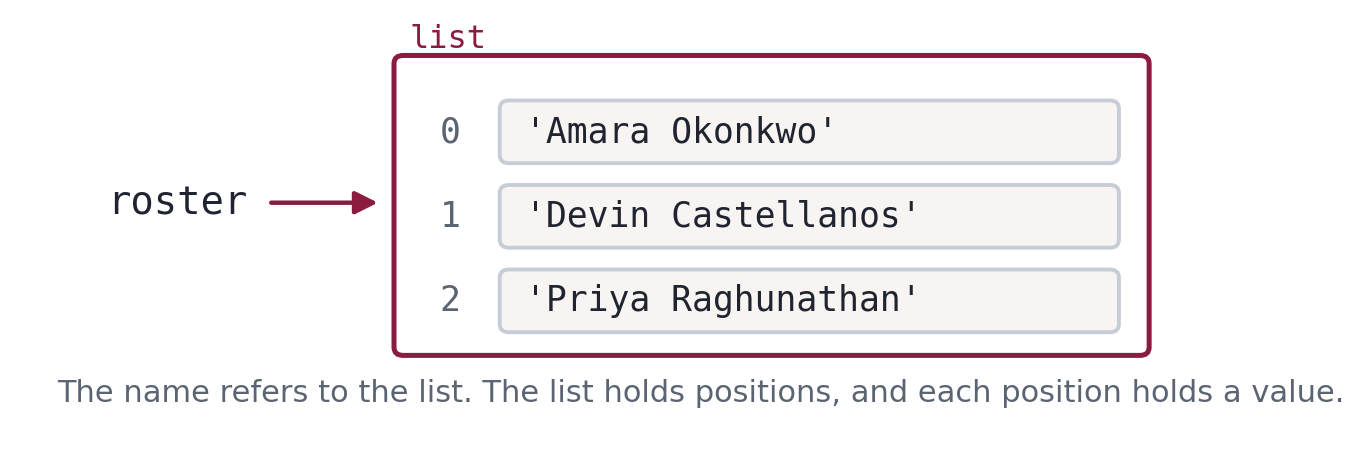

In [ ]:
roster[0]

In [ ]:
roster[-1]

In [ ]:
ug_gpas[0:3]

In [ ]:
%%expect IndexError
roster[10]

Ten elements means valid indices `0` through `9`. `roster[10]` is one
past the end - the same off-by-one you met with strings, and the reason
`len(roster) - 1` is the last valid index.

## Lists are mutable

Here's where lists differ from strings in a way that matters. Strings are
immutable - no method changes one in place. Lists **are** mutable: you can assign
to a position and change the list itself.

In [ ]:
scores = [88, 92, 79]
scores[0] = 95
scores

Try the equivalent on a string and Python refuses:

In [ ]:
%%expect TypeError
name = 'Amara'
name[0] = 'X'

That TypeError - `'str' object does not support item assignment` - is
Python saying strings are immutable. It's a distinction you'll rely on later:
mutability is why a list can be built up piece by piece, and immutability is why
a string is safe to pass around without worrying that something will change it.

## Growing a list

`.append()` adds one element to the end. Note that it modifies the list in place
and returns nothing:

In [ ]:
scores = [88, 92, 79]
scores.append(93)
scores

`.extend()` adds *all* the elements of another list:

In [ ]:
scores.extend([85, 91])
scores

Now the contrast that catches everyone. What if you `append` a list
instead of extending?

> **Predict.** `scores` has 6 elements. After `scores.append([70, 75])`, what is `len(scores)`?
>
> Commit to an answer before you run the next cell.

In [ ]:
scores = [88, 92, 79, 93, 85, 91]
scores.append([70, 75])
print(scores)
print(f"length: {len(scores)}")

**What happened.** Length `7`, not `8`.

`.append()` adds **one** element, and that one element happens to itself be a
list. You get a **nested** list: six numbers and then a list sitting in position
6. Look at the output and you can see the inner brackets.

`.extend()` unpacks; `.append()` wraps. When a "sum" or "mean" calculation
suddenly fails with a TypeError about lists and ints, this is usually why.

In [ ]:
scores[6]

In [ ]:
scores[6][0]

`scores[6]` is a list, so `scores[6][0]` reaches inside it. Double brackets are your signal that something is nested.

## Removing things

`.pop()` removes an element by index and *returns* it:

In [ ]:
letters = ['a', 'b', 'c', 'd']
removed = letters.pop(1)
print(f"removed {removed!r}, list is now {letters}")

`.remove()` deletes by value rather than position, and returns nothing:

In [ ]:
letters = ['a', 'b', 'c', 'd']
letters.remove('c')
letters

Ask it to remove something that isn't there and you get a `ValueError` - right type of argument, wrong content:

In [ ]:
%%expect ValueError
letters.remove('z')

## Testing membership

The `in` operator asks whether a value appears in a list. It returns a boolean,
so it drops straight into an `if`.

In [ ]:
'Nadia Haddad' in roster

In [ ]:
'Jamie Berrios' in roster

## Summarizing a list

Four built-in functions do most of what you'll want. `sum`, `min`, `max`, and
`len` - and with those four you can compute a mean.

In [ ]:
print(f"sum:  {sum(ug_gpas)}")
print(f"min:  {min(ug_gpas)}")
print(f"max:  {max(ug_gpas)}")
print(f"mean: {sum(ug_gpas) / len(ug_gpas):.3f}")

`sorted` returns a **new** list in order, leaving the original
alone:

In [ ]:
print(sorted(ug_gpas))
print(ug_gpas)

The original is untouched. If you want to keep the sorted version, assign it:

In [ ]:
ranked = sorted(ug_gpas, reverse=True)
ranked[:3]

`reverse=True` sorts high to low, so slicing the first three gives the top three GPAs. `sorted` works on strings too, alphabetically:

In [ ]:
sorted(['Nadia Haddad', 'Amara Okonkwo', 'Elliot Park'])

## Copying, and a trap

This is subtle, it bites hard, and it comes directly from the fact that lists
are mutable.

> **Predict.** After `backup = scores` and then `scores.append(999)`, what is `len(backup)`?
>
> Commit to an answer before you run the next cell.

In [ ]:
scores = [88, 92, 79]
backup = scores
scores.append(999)

print(f"scores: {scores}")
print(f"backup: {backup}")

**What happened.** `backup` changed too.

`backup = scores` did **not** copy the list. It gave the same list a second
name. Both names refer to one object in memory, so a change made through either
name is visible through both. This is called **aliasing**.

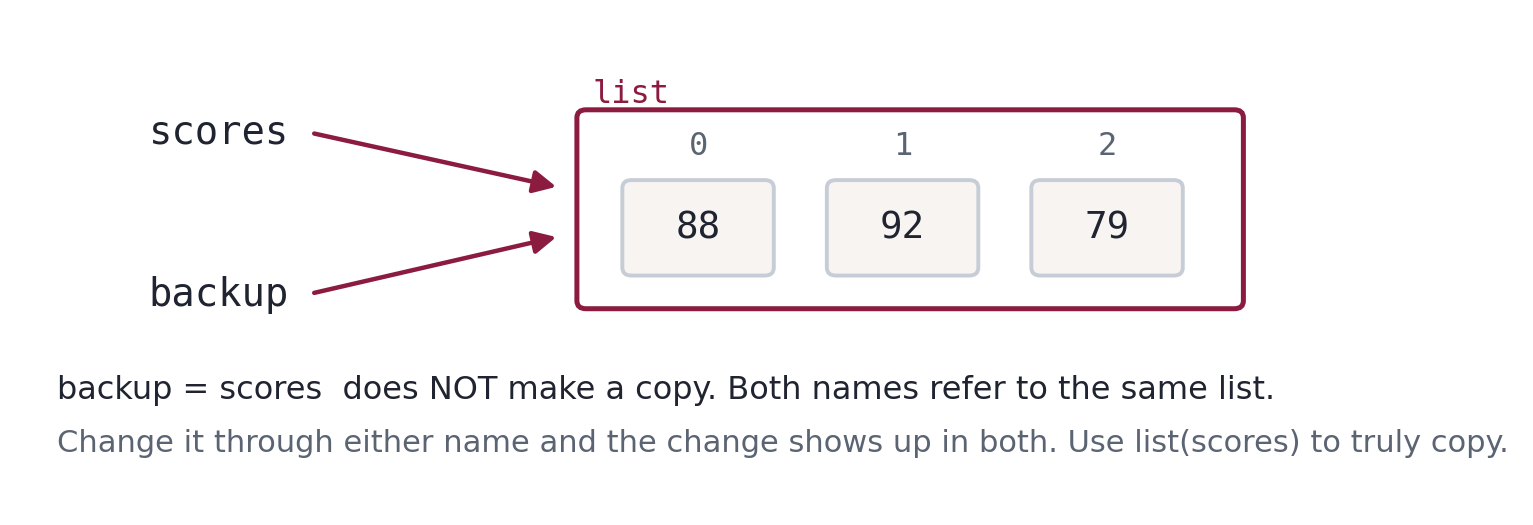

To make a real copy, use `list()` or a full slice:

In [ ]:
scores = [88, 92, 79]
real_copy = list(scores)      # or scores[:]
scores.append(999)

print(f"scores:    {scores}")
print(f"real_copy: {real_copy}")

This is the reason to be careful with mutable values in general, and
it's worth remembering when a DataFrame in Module 4 changes when you didn't
expect it to. Same idea, bigger object.

## Lists can hold anything

Elements don't have to share a type, and lists can contain lists:

In [ ]:
mixed = ['1003', 'Amara Okonkwo', 3.02, True, ['Biology', 'Chemistry']]

print(type(mixed[0]))
print(type(mixed[2]))
print(type(mixed[3]))
print(type(mixed[4]))

That flexibility is convenient and, in data work, usually a warning
sign - a column where the types vary is a column that will break something. One
of the first things NumPy does in Module 3 is take that flexibility away, on
purpose.

## Lists and strings

`.split()` turns a string into a list, which you saw in section 4. `.join()`
turns a list back into a string, and it's how you build readable output:

In [ ]:
row = "1003,Amara Okonkwo,Biology,3.02"
fields = row.split(",")
print(fields)
print(" | ".join(fields))

### Your turn

Using `ug_gpas`:

1. Print the highest and lowest GPA.
2. Print the mean, rounded to two decimal places, using an f-string.
3. Print the top three GPAs, highest first.
4. Print how many students have a GPA of at least 3.5. (You can do this with
   `sorted` and a slice - no loop needed yet. A loop would be cleaner, and
   that's section 8.)

In [ ]:
### ENTER CODE HERE ###

---
# 8 · Loops

You have ten messy names and a `clean_name` function. Cleaning them one at a
time would look like this:

```python
print(clean_name(roster[0]))
print(clean_name(roster[1]))
print(clean_name(roster[2]))
...
```

Ten lines, and every one of them is a chance to typo an index. With eighty
students it's unthinkable, and Berrios's real cohort has more than that.

A **loop** repeats a block of code once for each element in a sequence. This is
the point where programming starts to pay for itself.

In [ ]:
def clean_name(raw):
    """Return a name stripped of surrounding whitespace and title-cased."""
    return raw.strip().title()


for raw in roster:
    print(clean_name(raw))

Ten records, three lines of code, and it would be the same three
lines for ten thousand records.

## The anatomy of a for loop

```python
for raw in roster:
    print(clean_name(raw))
```

- `for` and `in` are keywords. The header ends with a colon; the body is indented.
- `raw` is the **loop variable**. You choose the name.
- `roster` is the sequence being **iterated** over.

What happens when it runs: `raw` is assigned the first element and the body
executes. Then `raw` is assigned the second element and the body executes again.
And so on until the sequence is exhausted, at which point the loop ends and
Python moves to the next line after the body.

The loop variable name is yours to pick and the loop doesn't care what it is:

In [ ]:
for cheeseburger in ["a", "b", "c"]:
    print(cheeseburger)

It works, and please don't. Name the loop variable after one element
of what you're looping over - `for raw in roster`, `for gpa in ug_gpas`,
`for student in cohort`. The name is documentation.

The *sequence* name, on the other hand, has to be real:

In [ ]:
%%expect NameError
for name in rooster:
    print(name)

A `NameError` and a typo. Read the name in the message - `rooster` - and the fix is obvious. Most NameErrors are misspellings.

You also can't loop over something that isn't a sequence:

In [ ]:
%%expect TypeError
for n in 10:
    print(n)

`'int' object is not iterable` - a single number isn't a collection of things. If you wanted the numbers 0 through 9, that's what `range` is for.

## range

`range` produces a sequence of integers. It's how you repeat something a fixed
number of times.

In [ ]:
for i in range(5):
    print(i)

Note it starts at `0` and stops *before* `5` - the same exclusive-stop
convention as slicing. `range(5)` gives you five numbers, which is usually what
you want. You can also give a start and a step:

In [ ]:
print(list(range(1, 6)))        # 1 through 5
print(list(range(0, 20, 5)))    # every 5th number

`range` doesn't build a list until you ask it to, which is why printing it directly is unhelpful:

In [ ]:
range(5)

## enumerate

Often you want the element *and* its position - to pair a name with a student
ID, say. You could loop over `range(len(roster))` and index in, but there's a
cleaner way.

In [ ]:
student_ids = [1003, 1089, 1024, 1044, 1032, 1050, 1069, 1002, 1063, 1026]

for i, raw in enumerate(roster):
    print(f"{student_ids[i]}  {clean_name(raw)}")

`enumerate` hands back two values each time through, and
`for i, raw in ...` catches them in two variables. You'll use this constantly.

### A detour: tuples, and unpacking

What `enumerate` actually hands back on each pass is a single value containing
two things - a **tuple**.

In [ ]:
# What one item from enumerate looks like on its own
item = list(enumerate(["a", "b"]))[0]
print(item)
print(type(item))

A tuple is an ordered collection, written with parentheses and
commas. It is very nearly a list, with one important difference: **a tuple is
immutable.** Once built, it cannot be changed.

In [ ]:
pair = (0, "Amara Okonkwo")
print(pair[0])          # index it like a list
print(pair[1])
print(len(pair))

In [ ]:
%%expect TypeError
pair[0] = 99

Same `does not support item assignment` message you saw when trying
to modify a string, and for the same reason - strings and tuples are both
immutable, lists and dictionaries are not.

**Unpacking** is what lets you pull a tuple apart into separate names in one
step:

In [ ]:
index, name = pair       # unpack two values into two names
print(index)
print(name)

That is exactly what `for i, raw in enumerate(roster)` is doing on
every pass through the loop. It's also how you'll take two values back from a
function later, and how you'll loop over a dictionary in section 9.

You do not need to build tuples yourself in this course. You do need to
recognize one when you see it, because Python hands them back constantly - and
because the error message when you try to modify one is otherwise baffling.

## The accumulator pattern

Here is the single most important loop pattern in data work. You want a total,
so you start at zero and add to a variable each time through.

In [ ]:
total = 0

for gpa in ug_gpas:
    total += gpa

print(f"total: {total}")
print(f"mean:  {total / len(ug_gpas):.3f}")

Three parts, and every accumulator has them:

1. **Initialize** before the loop - `total = 0`.
2. **Update** inside the loop - `total += gpa`.
3. **Use** after the loop - the mean.

Getting the initialization inside the loop by accident is a classic bug: `total`
would reset to zero every iteration and you'd end up with just the last value.

Counting works the same way, with `if` to decide what counts:

In [ ]:
high_achievers = 0

for gpa in ug_gpas:
    if gpa >= 3.5:
        high_achievers += 1

print(f"{high_achievers} of {len(ug_gpas)} students at or above 3.5")

And you can accumulate into a list instead of a number, with `.append()`:

In [ ]:
clean_roster = []

for raw in roster:
    clean_roster.append(clean_name(raw))

clean_roster

That's the payoff promised back in section 4: one cleaning
function, one loop, the whole cohort done.

Except look closely at the output before you celebrate.

> **Predict.** Read the ten cleaned names carefully. One of them is still wrong. Which, and why?
>
> Commit to an answer before you run the next cell.

In [ ]:
for name in clean_roster:
    print(f"[{name}]")     # brackets make the whitespace visible

**What happened.** `Sofia  Marchetti` still has two spaces between first and last
name.

`.strip()` only removes whitespace from the **ends** of a string, exactly as
promised in section 4. It has nothing to say about whitespace in the middle. Our
`clean_name` function did what it was written to do, and what it was written to
do was not enough.

This is the most common way data cleaning fails: not with an error, but with
code that runs happily and quietly leaves the problem in place. Had we not
printed the values and looked at them, this would have travelled all the way
into the Cabinet's report.

The fix is a small idiom worth memorizing. `.split()` breaks the string on *any*
run of whitespace and discards the empties; `" ".join(...)` puts it back
together with exactly one space between pieces:

In [ ]:
def clean_name(raw):
    """Return a name with outer whitespace stripped, inner whitespace
    collapsed to single spaces, and each word capitalized.
    """
    return " ".join(raw.split()).title()


clean_roster = []
for raw in roster:
    clean_roster.append(clean_name(raw))

for name in clean_roster:
    print(f"[{name}]")

Note that we didn't need `.strip()` at all anymore - `.split()`
already discards leading and trailing whitespace. One idiom replaced two
operations and fixed a bug.

**A caution about `.title()`.** It capitalizes the letter after every
non-letter, which is right more often than you'd expect but not always:

In [ ]:
print("JIAN-WEI CHEN".title())     # correct
print("mcdonald".title())          # not what a registrar wants
print("o'brien".title())           # debatable

Real name handling is genuinely hard and no one-line fix exists.
`.title()` is fine for this cohort. On real data you would check the output
against the source, which is the same lesson as above: **look at your values.**

`clean_roster` is now usable data.

## while loops

A `for` loop runs once per element. A **while** loop runs as long as a condition
stays true - which means you use it when you don't know in advance how many
iterations you need.

In [ ]:
countdown = 3

while countdown > 0:
    print(countdown)
    countdown -= 1

print("done")

The `countdown -= 1` is doing critical work. **If the condition never
becomes false, the loop never ends.** Remove that line and this cell would print
`3` forever until you interrupted the kernel.

That's not a hypothetical - it's the most common way a notebook hangs. If a cell
shows `[*]` and never finishes, an infinite loop is the first thing to suspect.
Use *Kernel → Interrupt* to stop it.

Because of that hazard, prefer `for` whenever you're iterating over a collection.
Reach for `while` only when the stopping condition genuinely isn't a count.

`break` exits a loop immediately:

In [ ]:
target = "Nadia Haddad"

for i, raw in enumerate(roster):
    if clean_name(raw) == target:
        print(f"found {target} at index {i}")
        break

Without `break` the loop would keep checking the remaining names for
no reason. On ten records that's free; on ten million it isn't.

## Nested loops

A loop can contain another loop. The inner one runs completely for every single
iteration of the outer one.

In [ ]:
terms = ["Fall", "Spring"]

for raw in roster[:3]:
    for term in terms:
        print(f"{clean_name(raw):20} {term}")

Three students times two terms is six lines. Watch the multiplication:
nesting a 1,000-element loop inside another 1,000-element loop is a million
iterations, and that's how a cell that "should be instant" takes four minutes.
Module 3 exists largely to make this kind of work fast.

### Your turn

Using `roster` and `ug_gpas` (same order, remember):

1. Loop over both together with `enumerate` and print each student's clean name
   and GPA, one per line, nicely aligned.
2. Count how many students are flagged `"at risk"` by the `standing` function
   from section 6.
3. Build a list called `honor_roll` containing the clean names of every student
   with a GPA of 3.5 or above.

Rebuild `standing` first if you've restarted the kernel since section 6.

In [ ]:
### ENTER CODE HERE ###

### Your turn

Predict the output of each loop before running it. All three are short; two of
them do something surprising.

```python
# A
for i in range(3):
    print(i)
print(i)

# B
total = 0
for n in [1, 2, 3]:
    total = 0
    total += n
print(total)

# C
values = [1, 2, 3]
for v in values:
    values.append(v)
    if len(values) > 8:
        break
print(values)
```

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** Three loop hazards, all worth remembering.

**A. The loop variable outlives the loop.** After `for i in range(3)` finishes,
`i` still exists and holds `2`, its final value. Occasionally useful; more often
a sign that you meant to use it inside the loop.

**B. Initialize accumulators *before* the loop, not inside it.** Block B prints
`3` rather than `6` because `total = 0` runs on every pass, throwing away
everything accumulated so far. Only the last value survives. This is easy to
write by accident and produces a plausible-looking wrong number rather than an
error, which makes it genuinely dangerous.

**C. Never modify a list while you are iterating over it.** Appending to the list
you're looping over means the loop keeps finding new elements - block C would run
forever without the `break`. Removing items while looping is just as bad: it
silently skips elements. **Build a new list instead**, the way `clean_roster` was
built above.

---
# 9 · Dictionaries

Parallel lists got you this far, but they have a real problem. To find Nadia
Haddad's GPA you have to search `roster` for her position and then use that
number to index `ug_gpas`. Sort one list without the other and every pairing is
silently wrong.

What you actually want is to look up a value *by name*. That's a **dictionary**.

## A dictionary is a mapping

A list maps positions to values - index `0` gets you the first element. A
dictionary maps **keys** to **values**, and the keys can be anything you like.

In [ ]:
gpa_by_name = {
    "Amara Okonkwo": 3.02,
    "Devin Castellanos": 1.99,
    "Priya Raghunathan": 2.8,
}
gpa_by_name

Curly braces, and each **item** is a `key: value` pair separated by a
colon. Look it up with square brackets - the same syntax as a list, but with a
key instead of a position:

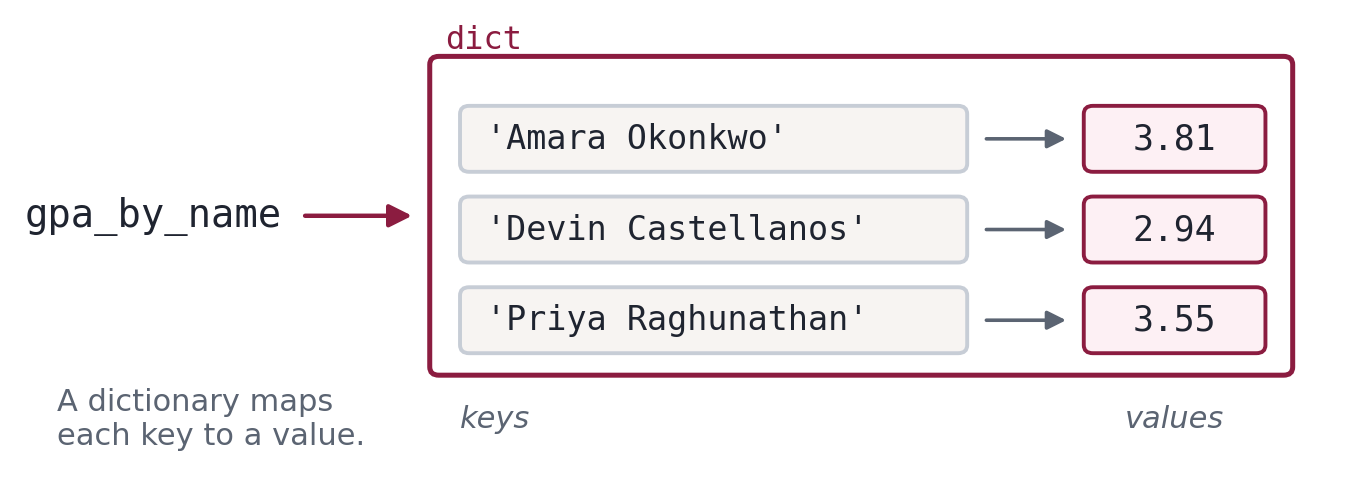

In [ ]:
gpa_by_name["Priya Raghunathan"]

No searching, no position tracking. And unlike parallel lists, the
pairing can't come apart.

Numeric indices don't work, because a dictionary has no order to index into:

In [ ]:
%%expect KeyError
gpa_by_name[0]

A **KeyError** means the key isn't in the dictionary - and `0` isn't
a key here. You'd get the same error asking for a student who isn't in the
cohort:

In [ ]:
%%expect KeyError
gpa_by_name["Jamie Berrios"]

## .get() and missing data

A KeyError stops your program. When you're not certain a key exists - which,
with real data, is always - `.get()` returns `None` instead of raising:

In [ ]:
print(gpa_by_name.get("Jamie Berrios"))
print(gpa_by_name.get("Amara Okonkwo"))

Or supply your own fallback as a second argument:

In [ ]:
gpa_by_name.get("Jamie Berrios", "not enrolled")

This becomes important in Module 4. Real cohort data has holes, and
whether you crash, skip, or substitute on a missing value is an analytical
decision with consequences - not a technicality.

## Changing a dictionary

Dictionaries are mutable. Assign to a key that doesn't exist and it's added:

In [ ]:
gpa_by_name["Marcus Webb"] = 2.6
gpa_by_name

Assign to a key that does exist and the old value is replaced - no warning, no error:

In [ ]:
gpa_by_name["Marcus Webb"] = 3.05
gpa_by_name

`del` removes an item:

In [ ]:
del gpa_by_name["Marcus Webb"]
gpa_by_name

`len` counts items, and `in` tests for a key:

In [ ]:
print(len(gpa_by_name))
print("Amara Okonkwo" in gpa_by_name)

> **Predict.** `3.02` is one of the values. What does `3.02 in gpa_by_name` return?
>
> Commit to an answer before you run the next cell.

In [ ]:
3.81 in gpa_by_name

**What happened.** `False`. **`in` checks keys, not values.**

This is a genuine gotcha, and the fix is to say what you mean - ask for the
values explicitly with `.values()`.

In [ ]:
3.81 in gpa_by_name.values()

## Keys, values, items

Three methods give you the parts of a dictionary.

In [ ]:
print(gpa_by_name.keys())
print(gpa_by_name.values())
print(gpa_by_name.items())

`.items()` gives you key-value pairs. Look at how they print:
`[('Amara Okonkwo', 3.02), ...]`. Those are **tuples**, the same thing
`enumerate` handed you in section 8 - which is why the same two-name unpacking
works on them.

## Looping over a dictionary

Loop over a dictionary directly and you get the **keys**:

In [ ]:
for name in gpa_by_name:
    print(name)

Loop over `.values()` for the values:

In [ ]:
for gpa in gpa_by_name.values():
    print(gpa)

And `.items()` for both at once - this is the one you'll reach for most:

In [ ]:
for name, gpa in gpa_by_name.items():
    print(f"{name:22} {gpa:.2f}")

That two-variable unpacking is the same mechanic as `enumerate`.

## Counting with a dictionary

Here is the pattern that makes dictionaries indispensable. You have a list of
majors, some repeated, and you want a count of each.

In [ ]:
majors = ["Biology", "Business", "Mathematics", "Psychology", "Economics",
          "Communications", "Computer Science", "Sociology", "Chemistry",
          "Engineering"]

fields = ["Science", "Business", "Science", "Social Science", "Business",
          "Humanities", "Science", "Social Science", "Science", "Science"]

counts = {}

for field in fields:
    if field in counts:
        counts[field] += 1
    else:
        counts[field] = 1

counts

Walk through the logic: for each field, if it's already a key, add
one to its count; if not, create it with a count of `1`. That `if/else` is
guarding against the KeyError you'd get from `counts[field] += 1` on a key that
doesn't exist yet.

`.get()` collapses it to one line, which is the idiom you'll see in real code:

In [ ]:
counts = {}

for field in fields:
    counts[field] = counts.get(field, 0) + 1

counts

That one line is dense, so take it apart from the inside out. On the
pass where `field` is `"Science"` for the second time:

| Step | Expression | Value |
|---|---|---|
| 1 | `counts.get("Science", 0)` | `1` - it's already a key, so we get its count |
| 2 | `... + 1` | `2` |
| 3 | `counts["Science"] = ...` | stores `2` back under the key |

And on the pass where `"Humanities"` appears for the *first* time:

| Step | Expression | Value |
|---|---|---|
| 1 | `counts.get("Humanities", 0)` | `0` - not a key yet, so the default |
| 2 | `... + 1` | `1` |
| 3 | `counts["Humanities"] = ...` | creates the key with `1` |

The whole trick is that `.get()` supplies a starting value for keys that don't
exist yet, so the same line handles both the first sighting and every one after.
Read it as: **take the current count, or zero if there isn't one, add one, store
it back.**

You now have a frequency table - the single most common summary in all of data
analysis. In Module 4 this is `value_counts()`, one method call. It's worth
having built it by hand once, so you know what that method is doing.

## A record as a dictionary

Dictionaries really come into their own for holding one thing with several
attributes. Instead of matching up ten parallel lists, put one student in one
dictionary:

In [ ]:
student = {
    "student_id": 1003,
    "name": "Amara Okonkwo",
    "ug_gpa": 3.02,
    "major": "Biology",
    "logins_per_week": 14,
}

print(student["name"])
print(f"{student['name']} studies {student['major']}")

Note the quote juggling in that f-string: the outer string uses
double quotes, so the key inside the braces uses single quotes. Mixing them up
is a common SyntaxError.

Now a **list of dictionaries** - one dictionary per student, all in a list. This
is the structure that finally survives sorting, and it's how most real data
arrives from an API or a JSON file.

In [ ]:
cohort = [
    {"student_id": 1003, "name": "Amara Okonkwo",     "ug_gpa": 3.02, "logins_per_week": 3.4},
    {"student_id": 1089, "name": "Devin Castellanos", "ug_gpa": 1.99, "logins_per_week": 0.4},
    {"student_id": 1024, "name": "Priya Raghunathan", "ug_gpa": 2.8, "logins_per_week": 4.4},
]

for record in cohort:
    print(f"{record['student_id']}  {record['name']:20} {record['ug_gpa']:.2f}")

Look at what that loop does: `record` is a dictionary, so
`record['name']` reaches inside it. Loop over a list, index into a dictionary.
Combining the two structures is most of practical Python.

And now sorting is safe, because each record carries its own fields:

In [ ]:
by_gpa = sorted(cohort, key=lambda r: r["ug_gpa"], reverse=True)

for record in by_gpa:
    print(f"{record['name']:20} {record['ug_gpa']:.2f}")

The `key=lambda r: r["ug_gpa"]` tells `sorted` which field to sort
on. `lambda` is a compact way to write a tiny function; you don't need to write
these yet, but you should recognize one when you see it, because pandas uses the
same idea constantly.

## What can be a key?

Keys have to be immutable. Strings, numbers, and booleans are fine. Lists are
not:

In [ ]:
%%expect TypeError
bad = {}
bad[["a", "b"]] = 1

`unhashable type: 'list'` is the message, and "hashable" is
effectively a synonym for "usable as a dictionary key." Values, on the other
hand, can be anything at all - including lists and other dictionaries:

In [ ]:
majors_by_field = {
    "Science": ["Biology", "Mathematics", "Computer Science", "Chemistry", "Engineering"],
    "Business": ["Business", "Economics"],
    "Social Science": ["Psychology", "Sociology"],
    "Humanities": ["Communications"],
}

for field, major_list in majors_by_field.items():
    print(f"{field:16} {len(major_list)} majors: {', '.join(major_list)}")

---
## The full cohort

Time to load everything. Below are all six of Berrios's tables, embedded
directly in the notebook - no file paths, no downloads, nothing to go wrong.

Each table is a dictionary keyed by `student_id`, with a dictionary of fields as
the value. That's the structure that makes a lookup like
`high_school[1003]["hs_gpa"]` read the way you'd say it out loud.

Run it and read it. This is the data for the rest of the course.

In [ ]:
# =============================================================================
# DTSC 520 -- Institutional Research cohort (n = 10)
# SYNTHETIC DATA. No real student records. These ten students are drawn
# from the same 100-student extract the capstone analyses, so the numbers
# you compute here are the numbers you will meet again there.
# Six tables, all keyed on student_id, matching the schema diagram above.
# =============================================================================

students = {
    1002: {"name": "Elliot Park",       "entry_term": "Spring 2021"},
    1003: {"name": "Amara Okonkwo",     "entry_term": "Fall 2019"},
    1024: {"name": "Priya Raghunathan", "entry_term": "Fall 2020"},
    1026: {"name": "Jian-Wei Chen",     "entry_term": "Fall 2021"},
    1032: {"name": "Sofia Marchetti",   "entry_term": "Fall 2020"},
    1044: {"name": "Marcus Webb",       "entry_term": "Spring 2020"},
    1050: {"name": "Tobias Lindqvist",  "entry_term": "Fall 2019"},
    1063: {"name": "Rosalind Achebe",   "entry_term": "Fall 2020"},
    1069: {"name": "Nadia Haddad",      "entry_term": "Fall 2021"},
    1089: {"name": "Devin Castellanos", "entry_term": "Fall 2019"},
}

high_school = {
    1002: {"hs_gpa": 2.2,  "sat": 1180, "attendance_rate": 0.866,  "clubs_count": 1},
    1003: {"hs_gpa": 2.72, "sat": 1280, "attendance_rate": 0.948,  "clubs_count": 2},
    1024: {"hs_gpa": 3.44, "sat": 1410, "attendance_rate": 0.95,   "clubs_count": 3},
    1026: {"hs_gpa": 2.79, "sat": 1290, "attendance_rate": 0.926,  "clubs_count": 4},
    1032: {"hs_gpa": 2.35, "sat": 1210, "attendance_rate": 0.865,  "clubs_count": 2},
    1044: {"hs_gpa": 2.5,  "sat": 1240, "attendance_rate": 0.913,  "clubs_count": 2},
    1050: {"hs_gpa": 1.89, "sat": 1120, "attendance_rate": 0.894,  "clubs_count": 1},
    1063: {"hs_gpa": 2.69, "sat": 1270, "attendance_rate": 0.893,  "clubs_count": 1},
    1069: {"hs_gpa": 2.55, "sat": 1240, "attendance_rate": 0.898,  "clubs_count": 2},
    1089: {"hs_gpa": 1.91, "sat": 1120, "attendance_rate": 0.83,   "clubs_count": 0},
}

undergraduate = {
    1002: {"ug_gpa": 2.48, "credits_earned": 124,  "major": "Sociology",       "internships": 0},
    1003: {"ug_gpa": 3.02, "credits_earned": 128,  "major": "Biology",         "internships": 0},
    1024: {"ug_gpa": 2.8,  "credits_earned": 126,  "major": "Mathematics",     "internships": 2},
    1026: {"ug_gpa": 2.81, "credits_earned": 126,  "major": "Engineering",     "internships": 1},
    1032: {"ug_gpa": 2.67, "credits_earned": 125,  "major": "Economics",       "internships": 0},
    1044: {"ug_gpa": 2.6,  "credits_earned": 125,  "major": "Psychology",      "internships": 1},
    1050: {"ug_gpa": 2.13, "credits_earned": 121,  "major": "Communications",  "internships": 0},
    1063: {"ug_gpa": 2.96, "credits_earned": 128,  "major": "Chemistry",       "internships": 1},
    1069: {"ug_gpa": 3.4,  "credits_earned": 131,  "major": "Computer Science", "internships": 1},
    1089: {"ug_gpa": 1.99, "credits_earned": 120,  "major": "Business",        "internships": 0},
}

# Note: Marcus Webb is still enrolled, so grad_gpa is None -- a real hole in
# real data. Section 11 and Module 4 both come back to this.
graduate = {
    1002: {"grad_gpa": 2.86,    "program": "MSW",            "completion_status": "completed"},
    1003: {"grad_gpa": 3.4,     "program": "MS Data Science", "completion_status": "completed"},
    1024: {"grad_gpa": 3.18,    "program": "MS Statistics",  "completion_status": "completed"},
    1026: {"grad_gpa": 3.19,    "program": "MS Engineering", "completion_status": "completed"},
    1032: {"grad_gpa": 3.05,    "program": "MS Analytics",   "completion_status": "completed"},
    1044: {"grad_gpa": None,    "program": "MS Counseling",  "completion_status": "in_progress"},
    1050: {"grad_gpa": 2.38,    "program": "MA Media",       "completion_status": "withdrawn"},
    1063: {"grad_gpa": 3.34,    "program": "MS Chemistry",   "completion_status": "completed"},
    1069: {"grad_gpa": 3.78,    "program": "MS Data Science", "completion_status": "completed"},
    1089: {"grad_gpa": 2.37,    "program": "MBA",            "completion_status": "completed"},
}

work_experience = {
    1002: {"years_experience": 4,   "role_level": "associate"},
    1003: {"years_experience": 2,   "role_level": "analyst"},
    1024: {"years_experience": 1,   "role_level": "analyst"},
    1026: {"years_experience": 3,   "role_level": "analyst"},
    1032: {"years_experience": 3,   "role_level": "analyst"},
    1044: {"years_experience": 8,   "role_level": "manager"},
    1050: {"years_experience": 6,   "role_level": "associate"},
    1063: {"years_experience": 0,   "role_level": "none"},
    1069: {"years_experience": 2,   "role_level": "analyst"},
    1089: {"years_experience": 5,   "role_level": "manager"},
}

# One student's LMS record is missing for this term. That is not an error in
# the extract - it is what the extract looks like.
lms_activity = {
    1002: {"logins_per_week": 0.8,     "time_on_task_hours": 2.5,    "submission_rate": 0.69},
    1003: {"logins_per_week": 3.4,     "time_on_task_hours": 1.8,    "submission_rate": 0.84},
    1024: {"logins_per_week": 4.4,     "time_on_task_hours": 6.6,    "submission_rate": 0.99},
    1026: {"logins_per_week": 3.4,     "time_on_task_hours": 4.3,    "submission_rate": 0.74},
    1032: {"logins_per_week": 3.2,     "time_on_task_hours": 2.4,    "submission_rate": 0.84},
    1044: {"logins_per_week": None,    "time_on_task_hours": None,   "submission_rate": None},
    1050: {"logins_per_week": 0.4,     "time_on_task_hours": 1.1,    "submission_rate": 0.68},
    1063: {"logins_per_week": 3.3,     "time_on_task_hours": 3.5,    "submission_rate": 0.75},
    1069: {"logins_per_week": 3.8,     "time_on_task_hours": 4.4,    "submission_rate": 0.94},
    1089: {"logins_per_week": 0.4,     "time_on_task_hours": 1.7,    "submission_rate": 0.7},
}

print(f"Loaded {len(students)} students across 6 tables.")

### `is` versus `==`

One more operator before we use the data, because it's about to appear and it
isn't the one you learned in section 6.

`==` asks whether two values are **equal**. `is` asks whether two names refer to
the **very same object** - the aliasing question from section 7.

In [ ]:
a = [1, 2, 3]
b = [1, 2, 3]      # same contents, separately built
c = a              # a second name for a's list

print(a == b)      # equal contents?
print(a is b)      # the same object?
print(a is c)      # this one is an alias

`a == b` is `True` because the contents match. `a is b` is `False`
because they are two separate lists that happen to look alike. `a is c` is
`True` because `c = a` never made a copy.

In practice you will use `==` almost always. The one place `is` is the correct
choice is checking for `None`:

```python
if value is None:        # do this
if value == None:        # works, but not the convention
```

There is exactly one `None` object in a running Python program, so identity is
the precise question, and `is None` is what every Python codebase writes. You'll
see it in the next cell and throughout the rest of this notebook.

Now a lookup crosses tables using the shared `student_id`, which is exactly what the schema diagram promised:

In [ ]:
sid = 1069

print(f"{students[sid]['name']} ({sid})")
print(f"  HS GPA         {high_school[sid]['hs_gpa']}")
print(f"  UG GPA         {undergraduate[sid]['ug_gpa']}  in {undergraduate[sid]['major']}")
print(f"  Grad program   {graduate[sid]['program']}")
print(f"  Logins/week    {lms_activity[sid]['logins_per_week']}")

In Module 4 this becomes a single `pd.merge`. For now, notice that
you *can* do it - and notice how much typing it takes. That gap is the argument
for pandas.

## The schema report

Berrios asked for one thing: open the data, understand its shape, tell her what's
there. That's a **schema report**, and you now have every tool you need to write
one - functions, loops, conditionals, dictionaries, f-strings.

In [ ]:
def describe_table(name, table):
    """Print the shape and field names of one cohort table."""
    row_count = len(table)
    first_key = list(table.keys())[0]
    field_names = list(table[first_key].keys())

    print(f"{name}")
    print(f"  rows:   {row_count}")
    print(f"  fields: {', '.join(field_names)}")

    # Count how many values are missing across the whole table.
    missing = 0
    for record in table.values():
        for value in record.values():
            if value is None:
                missing += 1
    if missing > 0:
        print(f"  MISSING: {missing} value(s)")
    print()


tables = {
    "students": students,
    "high_school": high_school,
    "undergraduate": undergraduate,
    "graduate": graduate,
    "work_experience": work_experience,
    "lms_activity": lms_activity,
}

print("=" * 60)
print("COHORT SCHEMA REPORT - prepared for J. Berrios")
print("=" * 60)
print()

for name, table in tables.items():
    describe_table(name, table)

That's a real deliverable. It uses a nested loop over a dictionary of
dictionaries, a `None` check, `.join()` on a list of field names, and f-string
alignment - everything from sections 3 through 9, doing actual work.

It also surfaces the thing Berrios most needs to know: **the graduate table has
a missing value.** Student 1044 is still enrolled, so there's no GPA to record.
That single `None` will break a naive average, and how you handle it is a
decision you'll make properly in Module 4.

### Your turn

Answer three of Berrios's questions using the six tables.

1. What is the mean undergraduate GPA across the cohort?
2. How many students are in each `completion_status` category? (Use the counting
   pattern.)
3. Print every student whose `logins_per_week` is below 8, with their name and
   undergraduate GPA. Are they the students you'd expect?

For question 1 you'll need to loop over `undergraduate.values()`.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** **Notice the `if logins is None: continue`.** Without it that
loop raises `TypeError: '<' not supported between instances of 'NoneType' and
'int'`, because one student has no LMS record this term.

That is not a flaw in the data, it is the data. Every real extract has holes,
and a comparison is where they usually surface - not at the point where the
value went missing, but three steps later in code that looks obviously correct.

You will meet this hole twice more: as `np.nan` in Module 3, and as a decision
you have to justify in Module 4.

---
# 10 · Modules

Python's built-in functions are a small fraction of what's available. A
**module** is a file of variables and functions someone else wrote, and
`import` makes it available to you.

The `math` module is a good first one.

In [ ]:
import math

No output - the import succeeded quietly. Now use the **dot
operator** to reach inside it. Read `math.sqrt` as "the `sqrt` function that
belongs to `math`":

In [ ]:
math.sqrt(144)

In [ ]:
math.pi

`math.pi` is a variable, not a function - no parentheses. `math.sqrt` is a function, so it takes an argument:

In [ ]:
f"A circle of radius 5 has area {math.pi * 5 ** 2:.4f}"

The dot operator is the same one you've been using for string methods
(`raw_name.strip()`). In both cases the dot means "belonging to." That's worth
noticing - one piece of syntax, one idea, several uses.

Forget the module prefix and Python has no idea what you mean:

In [ ]:
%%expect NameError
sqrt(144)

`sqrt` isn't a built-in - it lives in `math` and it stays there unless you say otherwise. Which you can:

In [ ]:
from math import sqrt
sqrt(144)

`from math import sqrt` copies just that one name into your notebook.
It's convenient and it has a cost: a reader now can't tell where `sqrt` came
from, and if two modules both define something called `sqrt`, whichever you
imported last silently wins. Prefer `import math` and the prefix for anything
you'll read again.

## Aliases

The pattern you'll see in every data science notebook ever written is `import X
as Y` - a shorter name for something you'll type hundreds of times.

In [ ]:
import math as m
m.sqrt(144)

Nobody actually aliases `math`. But the conventions in data science
are near-universal, and you should use them because everyone else does:

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
```

## When the module isn't there

Misspell a module name - or ask for one that isn't installed - and you get a
`ModuleNotFoundError`:

In [ ]:
%%expect ModuleNotFoundError
import maath

This is one of the most common errors you'll hit in a new
environment, and it usually means the package isn't installed rather than
misspelled. In a notebook you can install it right there:

```python
!pip install some-package
```

The `!` runs a shell command instead of Python. You'll rarely need it in Colab,
which comes with the data science stack preinstalled.

## Where you're going

Here's the module that Module 3 is about:

In [ ]:
import numpy as np

gpas = np.array([2.48, 3.02, 2.8, 2.81, 2.67, 2.6, 2.13, 2.96, 3.4, 1.99])

print(f"mean:   {gpas.mean():.3f}")
print(f"stdev:  {gpas.std():.3f}")
print(f"max:    {gpas.max()}")

Compare that to the accumulator loop you wrote in section 8. Same
mean, one method call. And `.std()` would have taken you fifteen lines by hand.

That's not the real reason NumPy exists, though. Try this:

In [ ]:
# Add 0.1 to every GPA -- the pure Python way
curved = []
for gpa in [2.48, 3.02, 2.8]:
    curved.append(gpa + 0.1)
print(curved)

# The NumPy way
print(gpas[:3] + 0.1)

One operation applied to a whole array at once, with no loop. That's
called **vectorization**, and on a real cohort it's not just shorter - it's
hundreds of times faster. Module 3 will race the two approaches against each
other so you can watch the difference.

**Note:** list comprehensions - the `[x + 0.1 for x in gpas]` syntax you may
have seen - are covered in Module 3 as well, right next to vectorization, where
the comparison actually means something.

---
# 11 · Reading errors

You've now triggered nine different error types on purpose. Time to consolidate,
because reading errors well is a larger part of this job than writing code well.

## A word about how this feels

Programmers make mistakes constantly. The mistakes are called **bugs** and
finding them is **debugging**, and if you're new to this, the volume of errors
can feel like evidence that you're bad at it. It isn't. Experienced programmers
generate errors at a similar rate; they just recognize them faster and panic
less.

One framing that helps: think of the computer as an employee with unusual
strengths - enormous speed, perfect precision, total consistency - and unusual
weaknesses - no judgment, no context, no ability to guess what you meant. Your
job is to be a good manager of that employee. When it does something absurd, it
is following your instructions exactly. The instructions were the problem, and
the error message is the employee telling you where it got stuck.

Frustration is normal and it's also expensive, because it makes you skip the step
where you actually read the message. Almost every error message tells you what
went wrong and where. Read it before you change anything.

## Anatomy of a traceback

Here's an error with several function calls behind it.

In [ ]:
def gpa_ratio(a, b):
    return a / b


def compare_students(sid_a, sid_b, ug_table, grad_table):
    """Compare one student's undergraduate GPA to another's graduate GPA."""
    return gpa_ratio(ug_table[sid_a]["ug_gpa"],
                     grad_table[sid_b]["grad_gpa"])

Note that both tables are passed in as **parameters** rather than
read from the surrounding notebook. A function that reaches out and grabs
whatever happens to be lying around works right up until something else in the
notebook changes, and then fails somewhere far away from the real cause. Every
helper function in this notebook takes its data as an argument, and yours should
too.

In [ ]:
%%expect TypeError
compare_students(1003, 1044, undergraduate, graduate)

Read a traceback **from the bottom up.**

- **The last line** names the error type and gives the message:
  `TypeError: unsupported operand type(s) for /: 'float' and 'NoneType'`.
  That's your actual problem - something is `None` when a number was expected.
- **The lines above it** are the call stack, most recent last. Reading up, you
  can see the failure happened inside `gpa_ratio`, which was called by
  `compare_students`, which was called by your cell.
- **The middle** shows you the offending line of code with a marker under it.

So: `gpa_ratio` divided by `None`. Where did the `None` come from? Student 1044's
graduate GPA - the missing value the schema report flagged. The error is three
functions deep, but its cause is a data problem you already knew about.

This is the normal shape of a real bug. The error surfaces far from where the
problem originated, and the traceback is the trail back to it.

## The error types you've met

| Error | Means | Typical cause |
|---|---|---|
| `SyntaxError` | Not valid Python at all | Missing colon, unclosed paren, `=` for `==` |
| `IndentationError` | Body missing or misaligned | Forgot to indent after a `:` |
| `NameError` | No such name | Typo, or you never ran the cell that defined it |
| `TypeError` | Wrong *kind* of value | `'126' / 3`, missing an argument, `None` in arithmetic |
| `ValueError` | Right kind, bad content | `int('3.7')`, `.remove()` on a missing item |
| `IndexError` | Position out of range | Off-by-one; `len(x)` instead of `len(x) - 1` |
| `KeyError` | No such dictionary key | Typo in a key, or the key genuinely isn't there |
| `AttributeError` | No such method on this type | Variable holds a different type than you assumed |
| `ZeroDivisionError` | Divided by zero | An empty list's length, usually |
| `ModuleNotFoundError` | Import failed | Package not installed, or misspelled |

Two habits will resolve most of these faster than anything else:

1. **Check the type.** `print(type(x))` answers a startling proportion of
   confusing errors, especially AttributeError and TypeError.
2. **Print the value right before the failing line.** Assumptions about what a
   variable holds are usually the bug.

## A good use of an AI assistant

Pasting an error message and asking what it means is a genuinely excellent use of
these tools. They're very good at it.

Ask well, though. Include the full traceback, not just the last line, and include
the code that produced it. Then ask *why* - "why is this None?" gets you a better
answer than "fix this."

### Your turn

Each cell below is broken. For each one: read the error, name the type, say what
caused it, and fix it. Don't guess-and-check - diagnose first, then edit.

Do them one at a time.

In [ ]:
# 1
scores = [88, 92, 79]
print(scores[3])

In [ ]:
# 2
record = {"name": "Amara Okonkwo", "ug_gpa": 3.02}
print(record["gpa"])

In [ ]:
# 3
gpa = 3.81
print("GPA is " + gpa)

In [ ]:
# 4
count = 0
for gpa in [3.81, 2.94]
    count += 1

In [ ]:
# 5
values = []
print(sum(values) / len(values))

In [ ]:
# 6
total = 0
for gpa in [2.48, 3.02, 2.8]:
total += gpa

---
# 12 · Notebook survival kit

Short section, all practical. These are the things that waste an afternoon if
nobody tells you.

## Cells share one memory, and order matters

A notebook is not a script. Cells run when you run them, and they all share the
same namespace. Which means the notebook you're looking at may not reflect the
state Python is actually in.

Run the next two cells in order, then run the *first* one again and watch the
value change.

In [ ]:
counter = 0
print(f"counter is {counter}")

In [ ]:
counter += 1
print(f"counter is now {counter}")

Run that second cell three times and `counter` is `3` - even though
nothing on screen says so. This is the single biggest source of "but it worked a
minute ago."

**The fix, and use it often: *Kernel → Restart & Run All*.** It clears everything
and runs the notebook top to bottom, which is the only way to know your notebook
actually works. Do it before you submit anything. A notebook that only runs in
the order you happened to click is a notebook that doesn't run.

## Shell commands

A `!` at the start of a line runs a shell command rather than Python. The main
use is installing packages:

```python
!pip install seaborn
```

Colab has the data science stack already, so you'll rarely need it. Note that
`!cd` doesn't work the way you'd expect - each `!` command runs in its own
temporary shell, so a directory change doesn't stick. Command-line work proper is
Module 6.

## Getting help without leaving the notebook

- `help(round)` prints the documentation.
- `?round` or `round?` opens it in a panel.
- **Tab completion:** type a variable name, then a dot, then press <kbd>Tab</kbd>
  to see every method available on it. Type a few letters first to filter. This
  is the fastest way to answer "what can this thing do?" and it works on
  everything.
- <kbd>Shift</kbd>+<kbd>Tab</kbd> inside a function's parentheses shows its
  arguments.

Tab completion in particular is worth building into your muscle memory now.

## input(), and why it's not in this notebook

You may see `input()` in other Python tutorials - it pauses and waits for the
user to type something:

```python
name = input("Enter your name: ")
print(f"Hello, {name}")
```

It works in Jupyter and Colab. It does **not** work in the browser-based
practice sims for this course, which run Python without a keyboard input
channel. More to the point, interactive prompts aren't how data science code
works: you read from files and databases, not from a person typing.

Note that `input()` always returns a **string**, even when the user types digits.
Convert explicitly:

```python
age = int(input("Age: "))        # int, correct
age = input("Age: ")             # str -- '25' + 1 is a TypeError
```

You may also encounter `eval(input(...))` in older material. Don't use it. It
executes whatever the user types as Python code, which is both a security hole
and a way to hide type bugs from yourself.

## Timing

One magic command worth knowing, because Module 3 is built on it. `%timeit` runs
a line repeatedly and reports how long it takes:

In [ ]:
%timeit sum(range(1000))

Keep that number in mind. In Module 3 you'll run the same
calculation with NumPy and race them.

---
# 13 · Challenges

Five problems. The first four are self-contained and drill the fundamentals; the
fifth is the one Berrios actually wants.

Work them without looking anything up first. When you're stuck, the order to
try things is: re-read the error, print the values involved, then ask for help.

## Challenge 1 - Classify a number

Write a function `describe_number(n)` that returns a string describing `n`:

- `"negative"` if it's below zero
- `"zero"` if it's exactly zero
- `"small"` if it's between 1 and 99
- `"large"` if it's 100 or more

Then test it on `-5`, `0`, `42`, and `1000`. Think carefully about the order of
your conditions.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** An `elif` chain lets each branch assume every earlier condition
was false. That is why the `"small"` branch only needs `n < 100` rather than
`0 < n < 100` - by the time Python reaches it, the negative and zero cases have
already been handled and returned. Ordering conditions well makes each one
simpler.

## Challenge 2 - Temperature converter, both ways

Write two functions, each with a docstring:

- `f_to_c(f)` returns Celsius from Fahrenheit: $(F - 32) \times 5/9$
- `c_to_f(c)` returns Fahrenheit from Celsius: $C \times 9/5 + 32$

Then verify they undo each other - convert 98.6°F to Celsius and back, and
confirm you get 98.6 again. Round to one decimal place in your output.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** **Never compare floats with `==`.**

The round trip above gives back `98.60000000000001`, not `98.6`. Nothing is
broken - floating-point arithmetic stores values in binary and cannot represent
most decimal fractions exactly, so tiny errors accumulate through a calculation.

`back == 98.6` is therefore `False`, which is why the check above rounds first.
Two safe patterns:

```python
round(back, 1) == original            # compare at a fixed precision
abs(back - original) < 0.0001         # or check the gap is small enough
```

This will matter in Modules 3 and 4, where you will compare computed columns and
occasionally get `False` from two numbers that print identically.

## Challenge 3 - The average, three ways

Here's a list of scores:

```python
scores = [88, 92, 79, 93, 85, 91, 74, 96]
```

Compute the mean three different ways, and confirm all three agree:

1. **By hand** - add the elements with explicit indexing (`scores[0] + scores[1] + ...`)
   and divide by the count you typed in yourself.
2. **With a loop** - the accumulator pattern from section 8.
3. **With built-ins** - `sum()` and `len()`.

Then answer this: if someone appends a ninth score to the list, which of your
three versions still gives the right answer? That's the actual lesson.

In [ ]:
scores = [88, 92, 79, 93, 85, 91, 74, 96]

### ENTER CODE HERE ###

**Takeaway.** **Never write the size of your data into your code.**

Append a ninth score and only versions 2 and 3 stay correct. Version 1 is wrong
twice over: it misses the new element, and it divides by a hardcoded `8`. It
still runs, and still returns a number that looks entirely reasonable.

Any time you type a literal count - `8`, `10`, `50` - ask where it came from. If
the answer is "that's how many rows there are today," replace it with `len()`.
This is the difference between code that works and code that keeps working.

## Challenge 4 - Factorial

The factorial of $n$ is $n \times (n-1) \times \cdots \times 2 \times 1$. So
$5! = 5 \times 4 \times 3 \times 2 \times 1 = 120$.

Write `factorial(n)` using a loop. Two things to think about:

- What should the accumulator start at? Not zero - think about why.
- What should `factorial(0)` return? Look it up if you're unsure; the
  mathematical convention is not arbitrary.

Test it on 0, 1, 5, and 10. (10! is 3,628,800.)

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** Two things this problem was built to teach.

**The accumulator's starting value depends on the operation.** For a sum you
start at `0`; for a product you must start at `1`, because anything multiplied by
zero is zero and you would get `0` every time. The identity value for the
operation is the right starting point.

**`range(1, n + 1)` needs that `+ 1`.** `range` excludes its stop value, so
`range(1, n)` would stop one short and quietly give you the wrong answer.
Off-by-one errors live in exactly this spot - whenever you write a `range` with
two arguments, check the last value it actually produces.

As a bonus, `factorial(0)` correctly returns `1`: `range(1, 1)` is empty, the loop
body never runs, and the initial value comes back untouched. That happens to match
the mathematical convention that 0! = 1, which is luck rather than design.

## Challenge 5 - Berrios's first briefing

This is the real one. Using the six cohort tables, produce a printed briefing
that answers the following. Write it as a set of functions with a loop at the
end, not as one long block.

1. **Cohort size** and the range of entry terms.
2. **Mean high school GPA and mean undergraduate GPA**, to two decimals. Did the
   cohort's GPA go up or down between the two?
3. **The engagement leader and laggard** - the students with the highest and
   lowest `logins_per_week`, with their names and undergraduate GPAs.
4. **Completion counts** - how many students completed, withdrew, or are in
   progress.
5. **A data-quality warning** - count and report any missing values, naming the
   affected student.
6. **One sentence of interpretation.** What would you tell Berrios? Be careful
   here: with ten students and no controls, what can you honestly claim?

That last part is the point of the exercise. The code is straightforward; the
discipline of not overclaiming is the skill the capstone will test.

Write your interpretation in a markdown cell below your code.

In [ ]:
### ENTER CODE HERE ###

### Model interpretation

*Compare yours to this after you've written your own.*

> The two least engaged students in the cohort are also its two lowest
> performers. That is suggestive, and it is not a finding. Note that the pattern
> is much weaker at the other end: our most engaged student by logins ranks only
> fifth of ten by GPA, so whatever relationship exists here is not a clean
> monotonic one. A real analysis would have to account for that asymmetry rather
> than report the tidy half of it.
>
> More fundamentally, ten students is far too few to rule out coincidence, and we
> have controlled for nothing - including the possibility that low engagement and
> low GPA are both consequences of some third factor such as work hours or
> financial stress. The direction of causation is unresolved too: disengagement
> may follow poor grades rather than cause them.
>
> One additional caution for the Cabinet. Our single missing value is a graduate
> GPA for a student still enrolled, which is benign. But engagement records are
> exactly the kind of data that tends to be *missing* for the students who are
> struggling most, and if that pattern holds at full scale, any analysis that
> drops incomplete records will be biased toward students who were already doing
> fine. We should check that before drawing conclusions.
>
> Recommendation: treat this as a hypothesis worth testing on the full cohort,
> not a finding.

If your interpretation was more confident than that, reread it and ask what
would have to be true for the claim to hold.

And if you wrote "students who engage more do better" without checking the top of
the distribution, notice what happened: you reported the half of the data that
agreed with you. That is the most common failure in applied data science, it is
rarely deliberate, and catching yourself doing it is a skill. Hedging
appropriately is not weakness - it's what keeps a five-year strategic plan from
being built on ten data points.

---

## What you've done

You loaded six tables, computed real summary statistics, wrote a schema report
and a briefing, and hedged your conclusions honestly. That's Stage 2 of the
capstone in miniature.

You also know why the next module exists. Every summary in this notebook took a
loop and an accumulator. In Module 3, `gpas.mean()` replaces all of it - and on
a cohort of eighty thousand instead of ten, that difference stops being about
elegance and starts being about whether the calculation finishes.

## Where to go if you want more

This notebook covers the fundamentals DTSC 520 needs, not all of Python. Left
out on purpose: sets, comprehensions, classes, file I/O, exception handling with
`try`/`except`, and recursion. Tuples got the short version in section 8 - enough
to recognize and unpack one, not enough to use them by choice.

If you're new to programming, **DTSC 575: Principles of Python Programming**
covers those properly, and taking it before the machine learning courses is a
good idea.

For self-study, both of the books this module draws on are free online and worth
your time:

- Allen Downey, *[Think
  Python](https://allendowney.github.io/ThinkPython/)* (3rd edition). Chapters 1,
  2, 3, 5, 9, and 10 overlap with this module; chapters 4, 6, 7, 8, and 11
  through 13 are the natural next steps, and they cover most of what was left
  out above.
- Jake VanderPlas, *[Python Data Science
  Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/)*. Chapter 1 is
  the deep version of section 12 here. Chapters 2 and 3 are Modules 3 and 4 of
  this course, so reading ahead there is time well spent.

See the acknowledgements at the top of this notebook for what came from where.